### Rahven's VENTURI — Jolpica Historical EDA & Analysis

> **Engineering Intelligence for Formula One**

#### 1. Purpose of this Notebook

This notebook is the historical analysis layer of Rahven's VENTURI.

The project uses two major Formula One data sources:

- **Jolpica** — the historical relational/statistical backbone
- **FastF1** — the high-resolution motorsport dataset used later for telemetry, race engineering, feature engineering and machine learning

Jolpica is particularly valuable because it allows us to study Formula One across the history of the modern Formula One World Championship, beginning in **1950** and extending into the current era.

Unlike FastF1, Jolpica is not primarily designed around high-frequency telemetry. Instead, it represents Formula One as a relational historical database containing entities and events such as:

- drivers
- teams/constructors
- circuits
- seasons
- Grands Prix
- sessions
- session entries
- laps
- pit stops
- championships

The processed Jolpica tables were prepared previously in:

`02_prepare_jolpica.ipynb`

This notebook therefore does **not** repeat the raw-data acquisition or preparation process. It works directly with the validated Parquet tables stored in:

`C:\F1-AI\data\processed\jolpica\`

---
#### 2. Why Jolpica Matters to VENTURI

Jolpica provides the historical foundation required to answer questions such as:

- How has Formula One changed across decades?
- Which drivers and teams have been historically successful?
- How has the F1 calendar evolved?
- Which circuits have remained important over multiple eras?
- How has championship competitiveness changed?
- How have race-weekend structures evolved?
- Which historical records are available consistently, and where does data completeness become a limitation?

These questions are important not only for historical exploration but also for identifying useful features and analytical opportunities for the future VENTURI platform.

---

#### 3. Jolpica vs FastF1

The two datasets serve different purposes.

| Jolpica | FastF1 |
|---|---|
| Historical relational database | High-resolution motorsport data |
| Driver/team/circuit history | Telemetry and timing |
| Championship records | Lap and sector analysis |
| Race/session structure | Weather and tyre information |
| Historical statistics | Race engineering |
| Historical EDA | Feature engineering |
| Website historical foundation | Future ML foundation |

The two datasets should therefore not be treated as interchangeable.

Jolpica helps VENTURI understand **Formula One as a historical system**.

FastF1 will later help VENTURI understand **Formula One as an engineering and performance system**.

---

#### 4. What This Notebook Will Investigate

The analysis will proceed from the structure of the database toward historical Formula One insights.

Major areas include:

1. Database structure and table relationships
2. Historical data coverage
3. Season and calendar evolution
4. Driver careers and performance
5. Team/constructor history
6. Circuit history
7. Driver and constructor championships
8. Session and weekend-format evolution
9. Lap-level historical data
10. Pit-stop history
11. Data completeness and historical limitations
12. Cross-domain historical insights

The objective is not to produce the largest possible number of charts.

The objective is to answer meaningful Formula One questions using evidence from the data.

---

#### 5. Analytical Philosophy

Throughout this notebook we distinguish between:

- **Observation** — what the data directly shows
- **Correlation** — variables that move together
- **Interpretation** — a reasonable explanation of an observed pattern
- **Hypothesis** — an explanation requiring further investigation
- **Evidence** — information strong enough to support a conclusion

Historical Formula One data is not equally complete across all decades.

Therefore, a modern record and a 1950s record should not automatically be treated as equivalent simply because both exist in the database.

Where appropriate, historical coverage and data completeness will be explicitly investigated.

---

#### 6. Expected Outcome

By the end of this notebook, we should understand:

> What the Jolpica database contains, how its entities and events relate, what historical Formula One questions it can answer, what meaningful patterns exist in the data, and where the historical data has limitations.

The resulting knowledge will form the historical analytical foundation for later VENTURI work involving:

- website data products
- FastF1 feature engineering
- machine learning
- API services
- the final interactive VENTURI platform

In [1]:
!pip install -U plotly kaleido jinja2

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: kaleido
    Found existing installation: kaleido 1.3.0
    Uninstalling kaleido-1.3.0:
      Successfully uninstalled kaleido-1.3.0



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import plotly.io as pio

# Force standalone HTML render


In [3]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")

In [4]:
PROJECT_ROOT = Path(r"C:\F1-AI")

JOLPICA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "jolpica"

JOLPICA_RAW = PROJECT_ROOT / "data" / "raw" / "jolpica"

print("Processed Jolpica path:")
print(JOLPICA_PROCESSED)

print("\nPath exists:", JOLPICA_PROCESSED.exists())

Processed Jolpica path:
C:\F1-AI\data\processed\jolpica

Path exists: True


### 1. Load the Existing Processed Jolpica Database

The preparation stage produced one Parquet file per Jolpica table.

Rather than hard-coding the expected table names, we first inspect the processed directory itself.

This is intentional.

The database inventory should be derived from the actual processed dataset rather than from assumptions in documentation.

This also allows us to detect discrepancies such as:

- missing processed tables
- unexpected tables
- naming differences
- additional tables such as `formula_one_pitstop`

In [5]:
parquet_files = sorted(JOLPICA_PROCESSED.glob("*.parquet"))

print(f"Parquet tables found: {len(parquet_files)}")

for file in parquet_files:
    print(file.name)

Parquet tables found: 18
formula_one_baseteam.parquet
formula_one_championshipadjustment.parquet
formula_one_championshipsystem.parquet
formula_one_circuit.parquet
formula_one_driver.parquet
formula_one_driverchampionship.parquet
formula_one_lap.parquet
formula_one_penalty.parquet
formula_one_pitstop.parquet
formula_one_pointsystem.parquet
formula_one_round.parquet
formula_one_roundentry.parquet
formula_one_season.parquet
formula_one_session.parquet
formula_one_sessionentry.parquet
formula_one_team.parquet
formula_one_teamchampionship.parquet
formula_one_teamdriver.parquet


In [6]:
tables = {}

for file in parquet_files:
    table_name = file.stem
    tables[table_name] = pd.read_parquet(file)

print(f"Loaded {len(tables)} tables.\n")

for table_name, df in tables.items():
    print(f"{table_name:<40} {df.shape}")

Loaded 18 tables.

formula_one_baseteam                     (0, 3)
formula_one_championshipadjustment       (3, 7)
formula_one_championshipsystem           (11, 10)
formula_one_circuit                      (78, 11)
formula_one_driver                       (881, 11)
formula_one_driverchampionship           (36003, 14)
formula_one_lap                          (715463, 9)
formula_one_penalty                      (0, 8)
formula_one_pitstop                      (12672, 7)
formula_one_pointsystem                  (24, 11)
formula_one_round                        (1173, 10)
formula_one_roundentry                   (27499, 5)
formula_one_season                       (77, 5)
formula_one_session                      (5130, 11)
formula_one_sessionentry                 (50706, 14)
formula_one_team                         (214, 9)
formula_one_teamchampionship             (14161, 14)
formula_one_teamdriver                   (3627, 6)


In [7]:
inventory = []

for table_name, df in tables.items():
    inventory.append({
        "table": table_name,
        "rows": len(df),
        "columns": len(df.columns),
        "memory_mb": df.memory_usage(deep=True).sum() / (1024 ** 2),
        "id_column": "id" in df.columns,
        "api_id_column": "api_id" in df.columns,
    })

inventory_df = (
    pd.DataFrame(inventory)
    .sort_values("rows", ascending=False)
    .reset_index(drop=True)
)

inventory_df

,table,rows,columns,memory_mb,id_column,api_id_column
0,formula_one_lap,715463,9,178.691120,True,True
1,formula_one_sessionentry,50706,14,14.801520,True,True
2,formula_one_driverchampionship,36003,14,5.287737,True,False
3,formula_one_roundentry,27499,5,2.622635,True,True
4,formula_one_teamchampionship,14161,14,2.079893,True,False
5,formula_one_pitstop,12672,7,2.597012,True,True
6,formula_one_session,5130,11,1.923358,True,True
7,formula_one_teamdriver,3627,6,0.373695,True,True
8,formula_one_round,1173,10,0.428498,True,True
9,formula_one_driver,881,11,0.448260,True,True


In [8]:
inventory_df.style.format({
    "memory_mb": "{:.2f}"
})

,table,rows,columns,memory_mb,id_column,api_id_column
0,formula_one_lap,715463,9,178.69,True,True
1,formula_one_sessionentry,50706,14,14.80,True,True
2,formula_one_driverchampionship,36003,14,5.29,True,False
3,formula_one_roundentry,27499,5,2.62,True,True
4,formula_one_teamchampionship,14161,14,2.08,True,False
5,formula_one_pitstop,12672,7,2.60,True,True
6,formula_one_session,5130,11,1.92,True,True
7,formula_one_teamdriver,3627,6,0.37,True,True
8,formula_one_round,1173,10,0.43,True,True
9,formula_one_driver,881,11,0.45,True,True


In [9]:
def inspect_table(table_name, n=5):
    df = tables[table_name]
    
    print(f"TABLE: {table_name}")
    print("=" * (len(table_name) + 7))
    print(f"Shape: {df.shape}")
    
    print("\nColumns:")
    print(list(df.columns))
    
    print("\nSample:")
    display(df.head(n))

In [10]:
important_tables = [
    "formula_one_driver",
    "formula_one_team",
    "formula_one_circuit",
    "formula_one_season",
    "formula_one_round",
    "formula_one_session",
    "formula_one_roundentry",
    "formula_one_sessionentry",
    "formula_one_lap",
    "formula_one_teamdriver",
    "formula_one_driverchampionship",
    "formula_one_teamchampionship",
    "formula_one_pitstop",
]

for table_name in important_tables:
    if table_name in tables:
        inspect_table(table_name, n=5)

TABLE: formula_one_driver
Shape: (881, 11)

Columns:
['id', 'abbreviation', 'api_id', 'country_code', 'date_of_birth', 'forename', 'nationality', 'permanent_car_number', 'reference', 'surname', 'wikipedia']

Sample:


,id,abbreviation,api_id,country_code,date_of_birth,forename,nationality,permanent_car_number,reference,surname,wikipedia
0,1,None,driver_NNme7ruE,ITA,1906-10-30,Nino,Italian,NaN,farina,Farina,http://en.wikipedia.org/wiki/Nino_Farina
1,2,None,driver_oSJ2AZ19,ITA,1898-06-09,Luigi,Italian,NaN,fagioli,Fagioli,http://en.wikipedia.org/wiki/Luigi_Fagioli
2,3,None,driver_K1dAqP21,GBR,1911-07-02,Reg,British,NaN,reg_parnell,Parnell,http://en.wikipedia.org/wiki/Reg_Parnell
3,4,None,driver_mMgKa2QC,FRA,1904-10-08,Yves,French,NaN,cabantous,Cabantous,http://en.wikipedia.org/wiki/Yves_Giraud_Caban...
4,5,None,driver_JBHqCjL6,FRA,1905-11-05,Louis,French,NaN,rosier,Rosier,http://en.wikipedia.org/wiki/Louis_Rosier


TABLE: formula_one_team
Shape: (214, 9)

Columns:
['id', 'api_id', 'base_team_id', 'country_code', 'name', 'nationality', 'primary_color', 'reference', 'wikipedia']

Sample:


,id,api_id,base_team_id,country_code,name,nationality,primary_color,reference,wikipedia
0,1,team_1XDKqgNu,NaN,CHE,Alfa Romeo,Swiss,None,alfa,https://en.wikipedia.org/wiki/Alfa_Romeo_in_Fo...
1,2,team_e9i5UU0k,NaN,ITA,Maserati,Italian,None,maserati,https://en.wikipedia.org/wiki/Maserati
2,3,team_R6ZNEH9U,NaN,GBR,Alta,British,None,alta,https://en.wikipedia.org/wiki/Alta_Car_and_Eng...
3,4,team_88ODtUbG,NaN,GBR,ERA,British,None,era,https://en.wikipedia.org/wiki/English_Racing_A...
4,5,team_IlAsz4uS,NaN,FRA,Talbot-Lago,French,None,lago,https://en.wikipedia.org/wiki/Talbot-Lago


TABLE: formula_one_circuit
Shape: (78, 11)

Columns:
['id', 'altitude', 'api_id', 'country', 'country_code', 'latitude', 'locality', 'longitude', 'name', 'reference', 'wikipedia']

Sample:


...

,id,adjustment_type,driver_id,highest_finish,is_eligible,points,position,round_id,round_number,season_id,session_id,session_number,win_count,year
0,425647,0,847,NaN,t,0.0,1.0,NaN,1,NaN,5134,4,0,2026
1,425648,0,857,NaN,t,0.0,2.0,NaN,1,NaN,5134,4,0,2026
2,425649,0,795,NaN,t,0.0,3.0,NaN,1,NaN,5134,4,0,2026
3,425650,0,845,NaN,t,0.0,4.0,NaN,1,NaN,5134,4,0,2026
4,425651,0,864,NaN,t,0.0,5.0,NaN,1,NaN,5134,4,0,2026


TABLE: formula_one_teamchampionship
Shape: (14161, 14)

Columns:
['id', 'adjustment_type', 'highest_finish', 'is_eligible', 'points', 'position', 'round_id', 'round_number', 'season_id', 'session_id', 'session_number', 'team_id', 'win_count', 'year']

Sample:


,id,adjustment_type,highest_finish,is_eligible,points,position,round_id,round_number,season_id,session_id,session_number,team_id,win_count,year
0,197289,0,NaN,t,0.0,1.0,NaN,1,NaN,5134,4,191,0,2026
1,197290,0,NaN,t,0.0,2.0,NaN,1,NaN,5134,4,141,0,2026
2,197291,0,NaN,t,0.0,3.0,NaN,1,NaN,5134,4,64,0,2026
3,197292,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,6,0,2026
4,197293,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,207,0,2026


TABLE: formula_one_pitstop
Shape: (12672, 7)

Columns:
['id', 'api_id', 'duration', 'lap_id', 'local_timestamp', 'number', 'session_entry_id']

Sample:


,id,api_id,duration,lap_id,local_timestamp,number,session_entry_id
0,1,pitstop_IYavKg2C,00:00:24.036,275638,17:59:17,2,27696
1,2,pitstop_XDzyA9tn,00:00:22.603,275672,17:25:17,1,27696
2,3,pitstop_c0OV7PJY,00:00:23.227,275742,17:28:24,1,27700
3,4,pitstop_SFBiesKg,00:00:23.199,275746,17:59:29,2,27700
4,5,pitstop_ZS3hcaW8,00:00:24.535,275769,17:28:39,1,27704


## **F1 Calendar Table**
--------------------------------------------

**Grain Check** of `formula_one_round` table

In [11]:
round_df = tables['formula_one_round']
total_rows = len(round_df)
unique_ids = round_df['id'].nunique()

print(f"Total_rows : {total_rows}")
print(f"UNique 'id' values : {unique_ids}")
print(f"Grain confirmed ? : {total_rows == unique_ids}")

Total_rows : 1173
UNique 'id' values : 1173
Grain confirmed ? : True


Checking whether `round.circuit_id` is same refernce to `circuit.id`

In [12]:
round_df = tables['formula_one_round']
circuit_df = tables['formula_one_circuit']

round_circuit_ids = set(round_df['circuit_id'].dropna())
valid_circuit_ids = set(circuit_df['id'])

orphan_circuit_ids = round_circuit_ids - valid_circuit_ids

print(f"Unique circuit_id values in round table : {len(round_circuit_ids)}")
print(f"Valid circuit ids in circuit table       : {len(valid_circuit_ids)}")
print(f"Orphan circuit_id values (broken FK)     : {len(orphan_circuit_ids)}")

if orphan_circuit_ids:
    print("Orphan IDs :", orphan_circuit_ids)

Unique circuit_id values in round table : 78
Valid circuit ids in circuit table       : 78
Orphan circuit_id values (broken FK)     : 0


checking same for `season`

In [13]:
round_df['season_id'].nunique()

77

In [14]:
season_df = tables['formula_one_season']

round_season_ids =  set(round_df['season_id'].dropna())
valid_season_ids = set(season_df['id'])

orphan_season_ids =  round_season_ids - valid_season_ids

print(f"Unique season_id in round table : {len(round_season_ids)}")
print(f"Valid season ids                : {len(valid_season_ids)}")
print(f"Orphan season_id (broken FK)     : {len(orphan_season_ids)}")

Unique season_id in round table : 77
Valid season ids                : 77
Orphan season_id (broken FK)     : 0


Joining Season + round + circuit for a meaningfull F1 Calendar history, i.e **`calendar_df`**

In [15]:
calendar_df = (
    round_df.merge(
        season_df[['id','year']],
        left_on = 'season_id',
        right_on = 'id',
        suffixes = ("","_season")
    )
    .merge(
        circuit_df[['id','name','country','country_code']],
        left_on = 'circuit_id',
        right_on = 'id',
        suffixes = ("","_circuit")
    )
)
print(f"round_df rows : {len(round_df)}")
print(f"calendar_df rows : {len(calendar_df)}")

round_df rows : 1173
calendar_df rows : 1173


In [16]:
print(f"round_df")

round_df


In [17]:
calendar_df

,id,api_id,circuit_id,date,is_cancelled,name,number,race_number,season_id,wikipedia,id_season,year,id_circuit,name_circuit,country,country_code
0,1,round_Pt9PwCgv,1,1950-05-13,f,British Grand Prix,1.0,1.0,1,https://en.wikipedia.org/wiki/1950_British_Gra...,1,1950,1,Silverstone Circuit,UK,GBR
1,2,round_cAbLcO1L,2,1950-05-21,f,Monaco Grand Prix,2.0,2.0,1,https://en.wikipedia.org/wiki/1950_Monaco_Gran...,1,1950,2,Circuit de Monaco,Monaco,MCO
2,3,round_RhrrZnkp,3,1950-05-30,f,Indianapolis 500,3.0,3.0,1,https://en.wikipedia.org/wiki/1950_Indianapoli...,1,1950,3,Indianapolis Motor Speedway,USA,USA
3,4,round_bcZ0QJDy,4,1950-06-04,f,Swiss Grand Prix,4.0,4.0,1,https://en.wikipedia.org/wiki/1950_Swiss_Grand...,1,1950,4,Circuit Bremgarten,Switzerland,CHE
4,5,round_0hDWfNbp,5,1950-06-18,f,Belgian Grand Prix,5.0,5.0,1,https://en.wikipedia.org/wiki/1950_Belgian_Gra...,1,1950,5,Circuit de Spa-Francorchamps,Belgium,BEL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168,1193,round_FoE51DGC,23,2026-11-01,f,Mexico City Grand Prix,18.0,1167.0,77,https://en.wikipedia.org/wiki/2026_Mexico_City...,77,2026,23,Autódromo Hermanos Rodríguez,Mexico,MEX
1169,1194,round_h4DL0SNq,37,2026-11-08,f,Brazilian Grand Prix,19.0,1168.0,77,https://en.wikipedia.org/wiki/2026_Brazilian_G...,77,2026,37,Autódromo José Carlos Pace,Brazil,BRA
1170,1195,round_iNZBT7AE,77,2026-11-22,f,Las Vegas Grand Prix,20.0,1169.0,77,https://en.wikipedia.org/wiki/2026_Las_Vegas_G...,77,2026,77,Las Vegas Strip Street Circuit,USA,USA
1171,1196,round_GLPBnOq8,74,2026-11-29,f,Qatar Grand Prix,21.0,1170.0,77,https://en.wikipedia.org/wiki/2026_Qatar_Grand...,77,2026,74,Losail International Circuit,Qatar,QAT


In [18]:
calendar_df = calendar_df.drop(columns=['id_season','id_circuit'])
calendar_df = calendar_df.rename(columns = {
    "name": "round_name",
    "name_circuit":"circuit_name"
})

In [19]:
calendar_df[['round_name','year','date','circuit_name','country']].head()

,round_name,year,date,circuit_name,country
0,British Grand Prix,1950,1950-05-13,Silverstone Circuit,UK
1,Monaco Grand Prix,1950,1950-05-21,Circuit de Monaco,Monaco
2,Indianapolis 500,1950,1950-05-30,Indianapolis Motor Speedway,USA
3,Swiss Grand Prix,1950,1950-06-04,Circuit Bremgarten,Switzerland
4,Belgian Grand Prix,1950,1950-06-18,Circuit de Spa-Francorchamps,Belgium


### **Analysis 1 : F1 Calendar Growth Over Time**

<Axes: title={'center': 'Number of F1 Races per season (1950-present)'}, xlabel='year'>

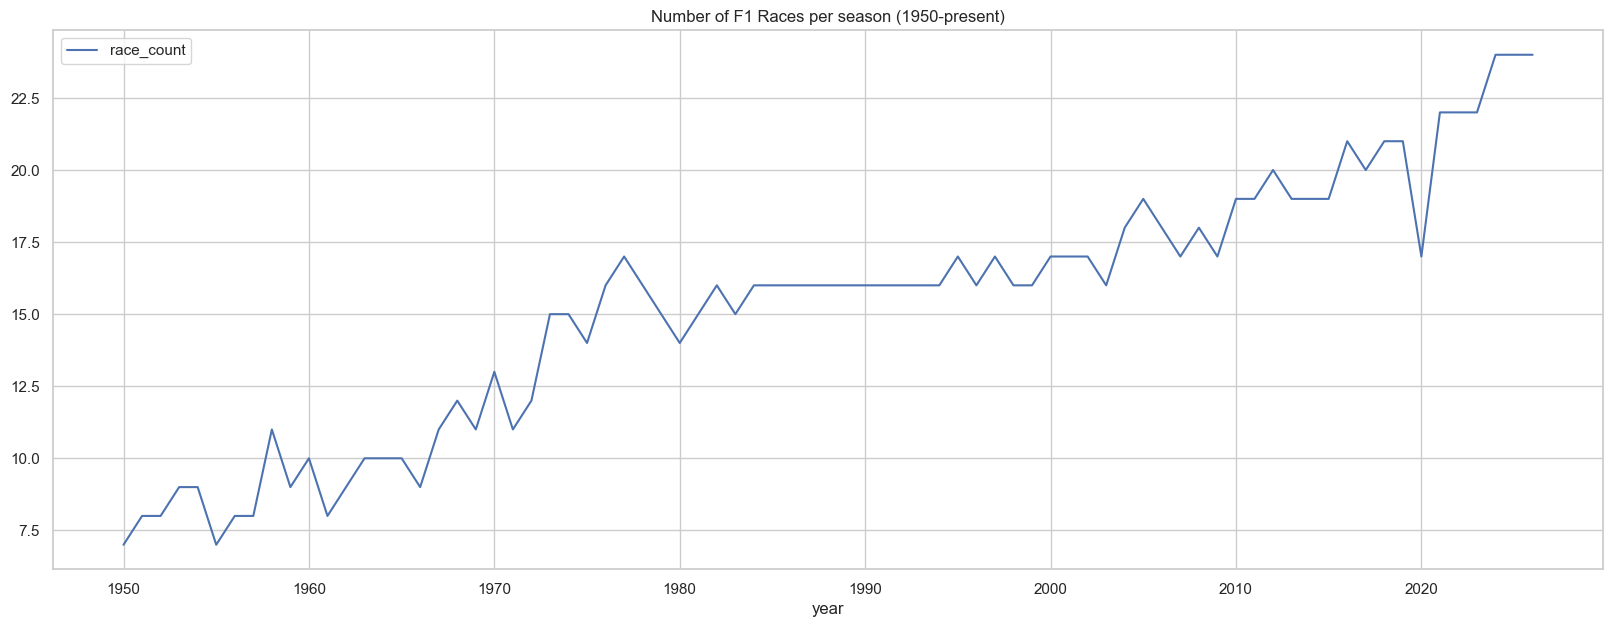

In [20]:
races_per_year = (
    calendar_df.groupby('year').size().reset_index(name="race_count")
)
races_per_year.plot(
    x="year",y="race_count",
    kind='line',figsize=(20,7), title='Number of F1 Races per season (1950-present)'
)

In [21]:
print(races_per_year)

    year  race_count
0   1950           7
1   1951           8
2   1952           8
3   1953           9
4   1954           9
5   1955           7
6   1956           8
7   1957           8
8   1958          11
9   1959           9
10  1960          10
11  1961           8
12  1962           9
13  1963          10
14  1964          10
15  1965          10
16  1966           9
17  1967          11
18  1968          12
19  1969          11
20  1970          13
21  1971          11
22  1972          12
23  1973          15
24  1974          15
25  1975          14
26  1976          16
27  1977          17
28  1978          16
29  1979          15
30  1980          14
31  1981          15
32  1982          16
33  1983          15
34  1984          16
35  1985          16
36  1986          16
37  1987          16
38  1988          16
39  1989          16
40  1990          16
41  1991          16
42  1992          16
43  1993          16
44  1994          16
45  1995          17
46  1996     

### **Analysis 2 : Which countries host most of the F1 races (all-time)?**

----------------------------------------------------

In [22]:
print(calendar_df['country'].unique())

['UK' 'Monaco' 'USA' 'Switzerland' 'Belgium' 'France' 'Italy' 'Germany'
 'Spain' 'Netherlands' 'Argentina' 'Portugal' 'Morocco' 'South Africa'
 'Mexico' 'Austria' 'Canada' 'Brazil' 'Sweden' 'Japan' 'Australia'
 'Hungary' 'Malaysia' 'Bahrain' 'China' 'Turkey' 'Singapore' 'UAE' 'Korea'
 'India' 'Russia' 'Azerbaijan' 'Qatar' 'Saudi Arabia']


In [23]:
country_race_counts = (
    calendar_df.groupby('country').size().reset_index(name='race_count').sort_values('race_count',ascending=False)
    .head(15)
)
print(country_race_counts)

        country  race_count
13        Italy         110
33          USA          85
32           UK          81
10      Germany          79
18       Monaco          72
5       Belgium          71
27        Spain          64
9        France          63
7        Canada          55
6        Brazil          53
14        Japan          42
2       Austria          41
11      Hungary          41
1     Australia          40
20  Netherlands          36


In [24]:
fig = px.bar(
    country_race_counts,
    x="race_count", y="country",
    orientation="h",
    color="race_count",
    color_continuous_scale="Reds",
    title="Top 15 Countries by Total F1 Races Hosted (1950–2026)"
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.update_layout(height=500)
fig.show()

### **Analysis 3 : Which country is leading to host most F1 races in past 10 years?**
___________________________________________

In [25]:
recent_calendar = calendar_df[calendar_df["year"]>=2017]

recent_country_counts = (
    recent_calendar.groupby("country").size().reset_index(name="race_count").sort_values("race_count",ascending=False).head(15)
)

fig = px.bar(
    recent_country_counts,
    x="race_count", y="country",
    orientation="h",
    color="race_count",
    color_continuous_scale="Blues",
    title="Top Countries by F1 Races Hosted (2017–2026)"
)
fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    height=500
)
fig.show()


Non-European venues like the USA, Bahrain, the UAE, and Azerbaijan have made it into the top 15—confirming that F1's recent focus has shifted towards the Middle East and new commercial markets, even as legacy circuits in Italy, the UK, and Austria remain strong.

### **Analysis 4 : Circuit longevity**

-------------------------------------------------

In [26]:
circuit_span = (
    calendar_df.groupby('circuit_name').agg(
        first_year=('year','min'),
        last_year=('year','max'),
        total_races = ('id','count')
    )
    .assign(years_active = lambda d:d['last_year']-d['first_year']+1).sort_values('years_active',ascending=False).head(15)
    .reset_index()
)

In [27]:
fig = px.bar(
    circuit_span,
    x="years_active", y="circuit_name",
    orientation="h",
    color="total_races",
    color_continuous_scale="reds",
    hover_data=["first_year", "last_year", "total_races"],
    title="Longest-Running F1 Circuits (Span in Years, colored by Total Races)"
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.update_layout(height=500)
fig.show()


> **Interpretation**

> A small group of circuits — Monza, Monaco, Silverstone, Spa — form the historical backbone of the F1 calendar. Their near-continuous presence across 70+ years suggests these venues are protected by tradition, contractual relationships, or strong commercial/fan value, rather than being replaced like newer venues often are.

> **Caveat**

> `years_active` measures the *span* between a circuit's first and last race, not continuous presence. A circuit could have taken a multi-year break mid-span and still show a long span — this chart alone can't tell us about gaps. To confirm true continuity, we'd need to check whether every year within the span actually has a race for that circuit.

---------------------------------
**Driver table grain check**

In [28]:
driver_df = tables['formula_one_driver']

total_rows = len(driver_df)
unique_ids= driver_df['id'].nunique()

print(f"total rows : {total_rows}")
print(f"Unique id values : {unique_ids}")
print(f"Grain_confirms ? : {total_rows == unique_ids}")

total rows : 881
Unique id values : 881
Grain_confirms ? : True


> The 'driver' table only provides basic driver information (name, nationality, date of birth)—details regarding which team they drove for and when are not included there. The 'teamdriver' table is used for that information.

**Team driver grain check and uniqueness**

In [29]:
teamdriver_df = tables['formula_one_teamdriver']

total_rows = len(teamdriver_df)
unique_ids = teamdriver_df['id'].nunique()

In [30]:
# Checking wether driver_id + season_id combo is unique ? or may be one driver drove for more than one team in a single season?

combo_unique = teamdriver_df.duplicated(subset=["driver_id","season_id"]).sum()

print(f"Total rows                 : {total_rows}")
print(f"Unique 'id'                : {unique_ids}")
print(f"Duplicate driver+season combos: {combo_unique}")

Total rows                 : 3627
Unique 'id'                : 3627
Duplicate driver+season combos: 348


> **As expected, there 348 cases where a single drive drive for multiple teams in a same season, becaus ein F1 , driver may switch the team mid-season**

In [31]:
dup_combos = (
    teamdriver_df[teamdriver_df.duplicated(subset=["driver_id","season_id"],keep=False)].sort_values(["driver_id","season_id"])
)

dup_combos.head(10)

,id,api_id,driver_id,role,season_id,team_id
2,3,teamdriver_d8PF1G74,3,NaN,1,1
76,77,teamdriver_EXVQUZTc,3,NaN,1,2
146,147,teamdriver_vV2tbvpJ,3,NaN,2,6
155,156,teamdriver_IeNwGR1e,3,NaN,2,34
423,424,teamdriver_bt6lPC0P,5,NaN,5,6
508,509,teamdriver_9LYCQmrP,5,NaN,5,2
231,232,teamdriver_rpCKX5Uc,12,NaN,3,36
244,245,teamdriver_3scG1tOm,12,NaN,3,8
264,265,teamdriver_xjP7tMmF,12,NaN,3,25
355,356,teamdriver_EccAhhfe,12,NaN,4,40


## **F1 Driver Career Table**
--------------------------------------

**Creating Driver career history dataset**

joining driver + teamdriver + team  --> will show career timeline, row by row

In [32]:
team_df = tables["formula_one_team"]

driver_career_df = (
    teamdriver_df.merge(
        driver_df[['id','forename','surname','nationality','date_of_birth']],
        left_on = "driver_id", right_on = "id",
        suffixes=("","_driver")
    )
    .merge(
        team_df[["id","name"]],
        left_on="team_id",right_on="id",
        suffixes=("","_team")
    )
    .merge(
        season_df[["id","year"]],
        left_on="season_id",right_on="id",
        suffixes=("","_season")
    )
)

print(f"team_driver_df rows : {len(teamdriver_df)}")
print(f"driver_career_df rows: {len(driver_career_df)}")

team_driver_df rows : 3627
driver_career_df rows: 3627


In [33]:
driver_career_df.head(10)

,id,api_id,driver_id,role,season_id,team_id,id_driver,forename,surname,nationality,date_of_birth,id_team,name,id_season,year
0,1,teamdriver_LSox06Od,1,NaN,1,1,1,Nino,Farina,Italian,1906-10-30,1,Alfa Romeo,1,1950
1,2,teamdriver_bLowFOCJ,2,NaN,1,1,2,Luigi,Fagioli,Italian,1898-06-09,1,Alfa Romeo,1,1950
2,3,teamdriver_d8PF1G74,3,NaN,1,1,3,Reg,Parnell,British,1911-07-02,1,Alfa Romeo,1,1950
3,4,teamdriver_DuMzxcI2,4,NaN,1,5,4,Yves,Cabantous,French,1904-10-08,5,Talbot-Lago,1,1950
4,5,teamdriver_0BTCGA9I,5,NaN,1,5,5,Louis,Rosier,French,1905-11-05,5,Talbot-Lago,1,1950
5,6,teamdriver_WLosNKTu,6,NaN,1,4,6,Bob,Gerard,British,1914-01-19,4,ERA,1,1950
6,7,teamdriver_eefZHC4n,7,NaN,1,4,7,Cuth,Harrison,British,1906-07-06,4,ERA,1,1950
7,8,teamdriver_KALDUuy4,8,NaN,1,5,8,Philippe,Étancelin,French,1896-12-28,5,Talbot-Lago,1,1950
8,9,teamdriver_pzWRMI8C,9,NaN,1,2,9,David,Hampshire,British,1917-12-29,2,Maserati,1,1950
9,10,teamdriver_1jgFtLvp,11,NaN,1,2,11,Joe,Fry,British,1915-10-26,2,Maserati,1,1950


In [34]:
# Cleaning the columns.
driver_career_df = driver_career_df.drop(columns=["id_driver", "id_team", "id_season"])
driver_career_df["driver_full_name"] = driver_career_df["forename"] + " " + driver_career_df["surname"]

driver_career_df.head(3)

,id,api_id,driver_id,role,season_id,team_id,forename,surname,nationality,date_of_birth,name,year,driver_full_name
0,1,teamdriver_LSox06Od,1,NaN,1,1,Nino,Farina,Italian,1906-10-30,Alfa Romeo,1950,Nino Farina
1,2,teamdriver_bLowFOCJ,2,NaN,1,1,Luigi,Fagioli,Italian,1898-06-09,Alfa Romeo,1950,Luigi Fagioli
2,3,teamdriver_d8PF1G74,3,NaN,1,1,Reg,Parnell,British,1911-07-02,Alfa Romeo,1950,Reg Parnell


### **Analysis 1 : Which driver had longest career ?**

------------------------------------------------------------

In [35]:
career_length = (
    driver_career_df.groupby(["driver_id","driver_full_name"])
    .agg(
        first_year = ("year","min"),
        last_year = ("year","max"),
        season_count=("year","nunique"),
        teams_count=("team_id","nunique"),
    )
    .assign(career_span = lambda d : d["last_year"]-d["first_year"] + 1).sort_values("career_span",ascending=False)
    .reset_index()
)

career_length.head(15)

,driver_id,driver_full_name,first_year,last_year,season_count,teams_count,career_span
0,763,Fernando Alonso,2001,2026,23,6,26
1,703,Michael Schumacher,1991,2012,19,4,22
2,762,Kimi Räikkönen,2001,2021,19,5,21
3,795,Lewis Hamilton,2007,2026,20,3,20
4,715,Rubens Barrichello,1993,2011,19,6,19
5,759,Jenson Button,2000,2017,18,7,18
6,277,Graham Hill,1958,1975,18,8,18
7,716,Luca Badoer,1993,2009,5,4,17
8,581,Riccardo Patrese,1977,1993,17,6,17
9,807,Nico Hülkenberg,2010,2026,15,8,17


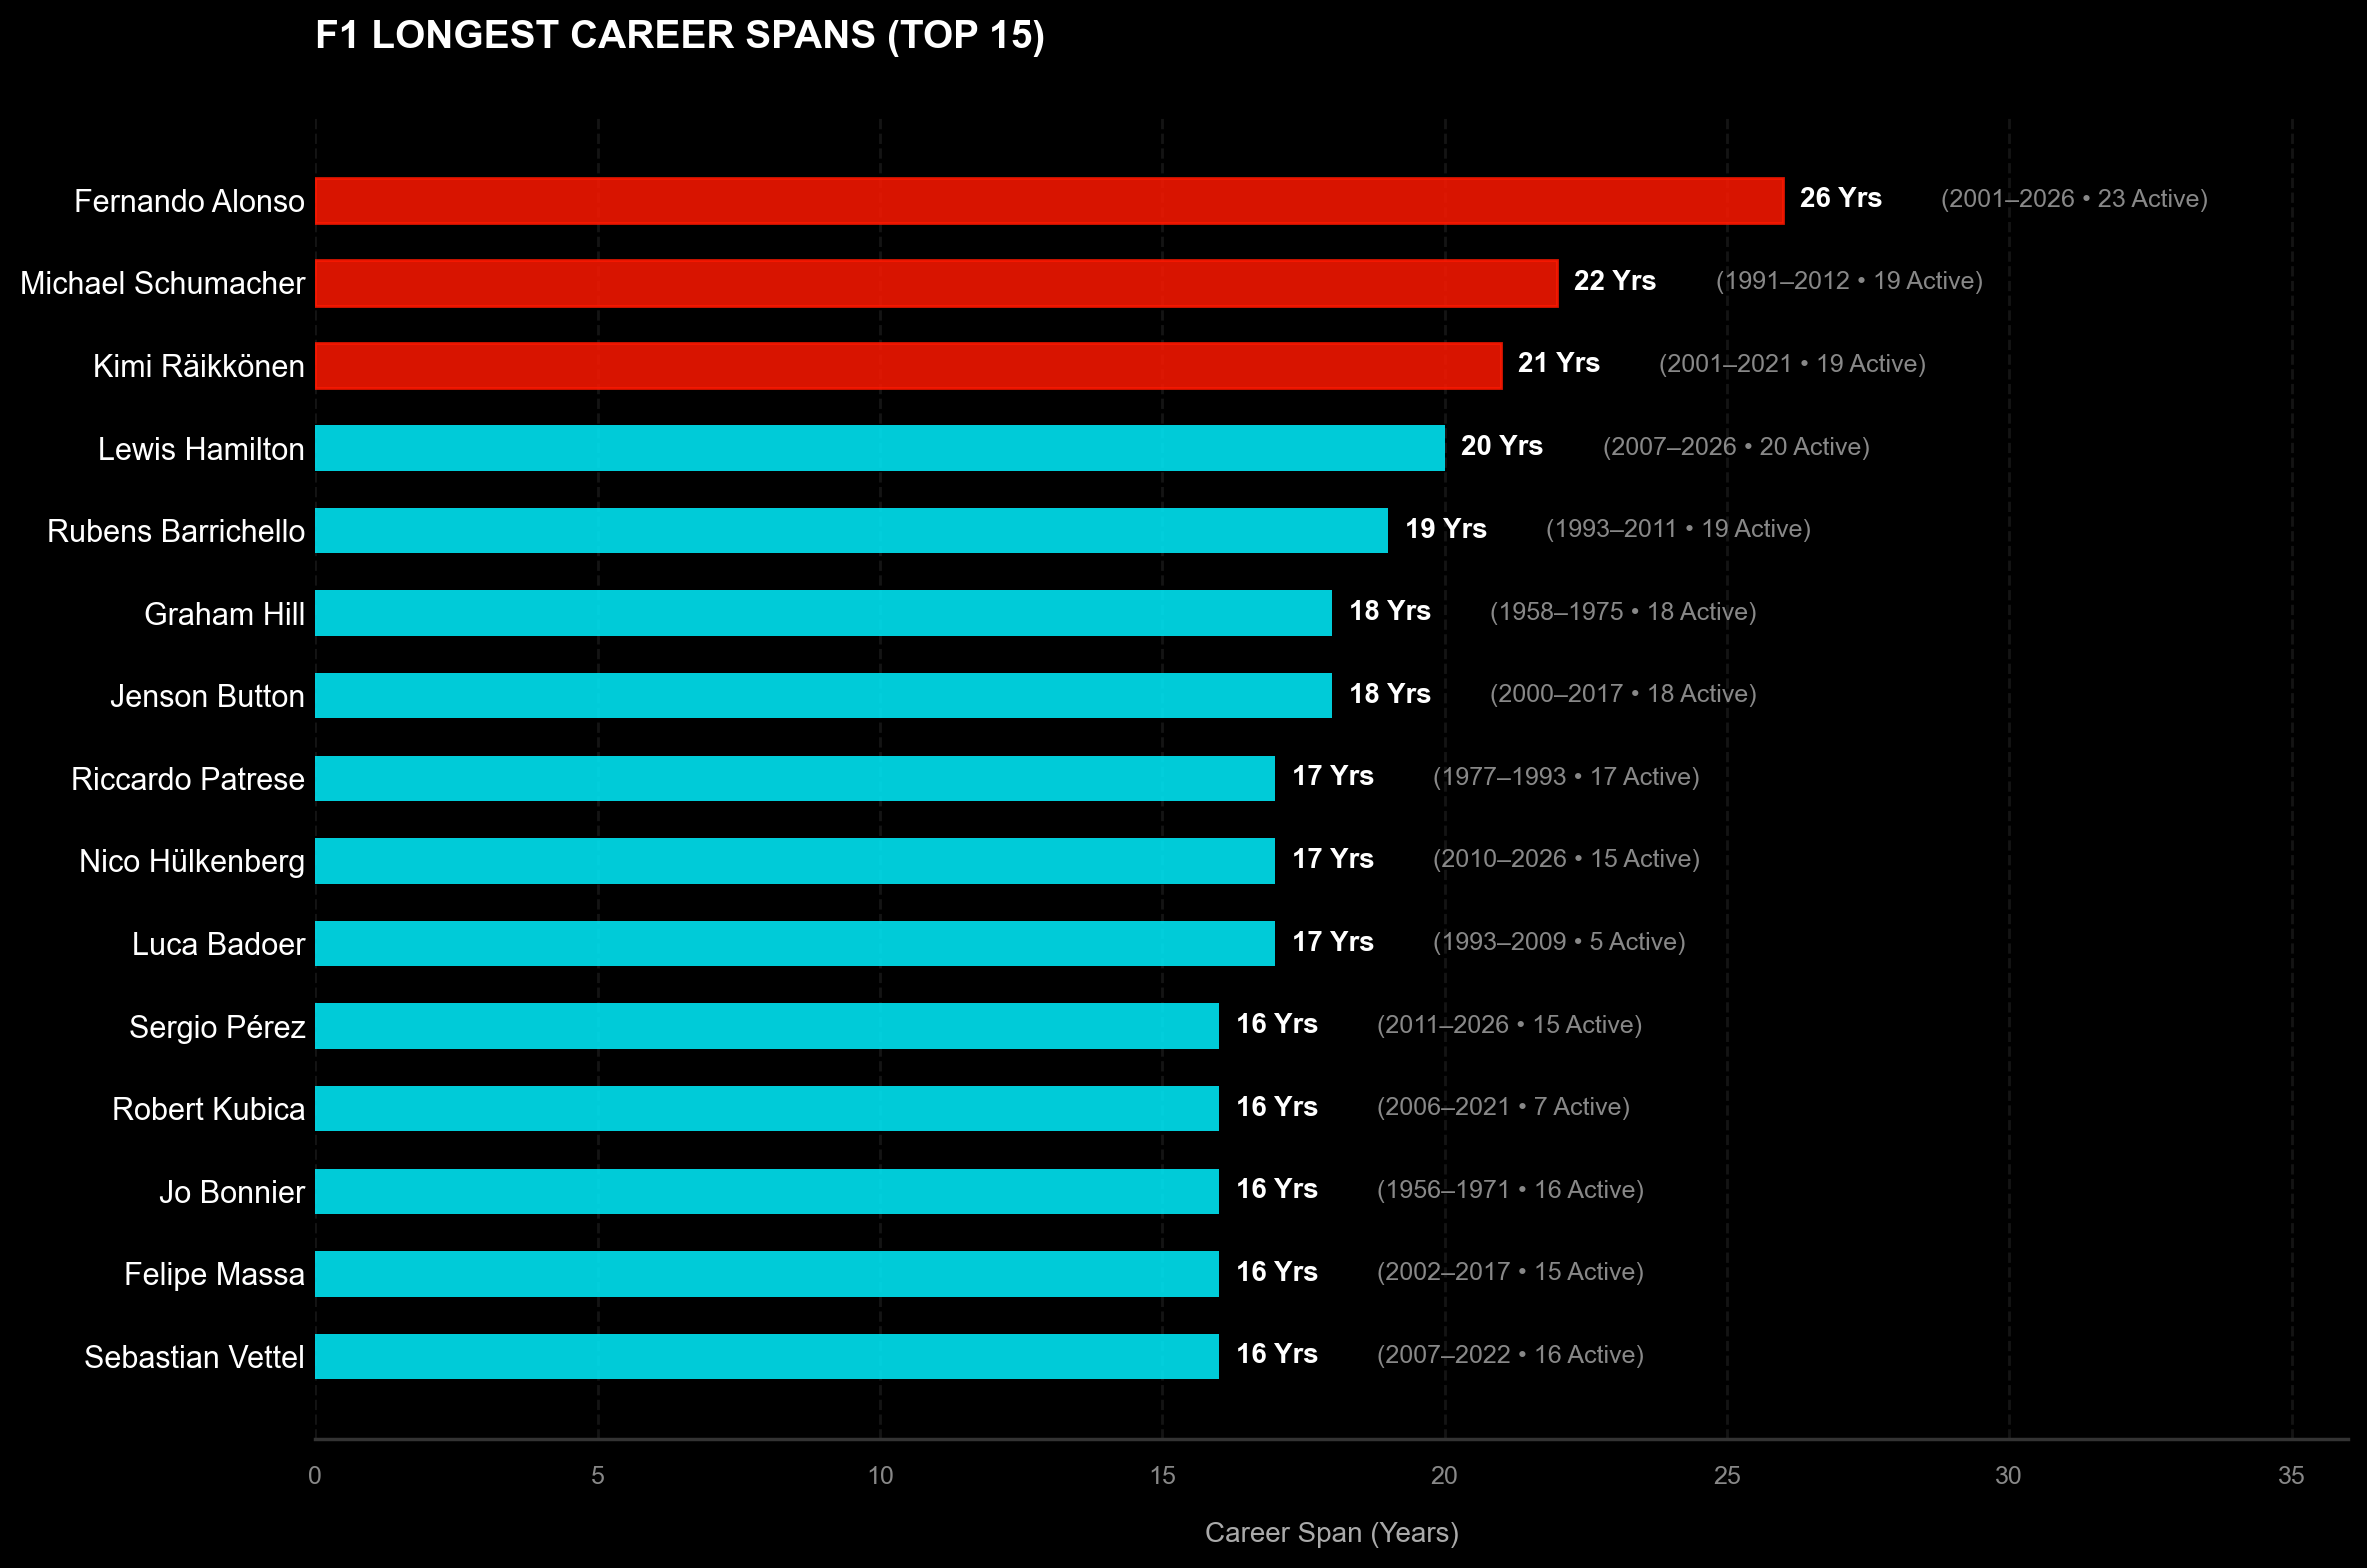

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix Indexing to prevent iterrows / KeyError bugs
df_plot = career_length.head(15).copy()
df_plot = df_plot.sort_values("career_span", ascending=True).reset_index(
    drop=True
)

# Dark Minimalist Theme Setup
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

# Main Horizontal Bars (Cyberpunk Cyan Color)
bars = ax.barh(
    y=df_plot["driver_full_name"],
    width=df_plot["career_span"],
    color="#00F0FF",
    height=0.55,
    alpha=0.85,
    edgecolor="none",
)

# Gradient / Highlighting top 3 drivers (F1 Red for top 3)
for i in range(len(df_plot) - 3, len(df_plot)):
    bars[i].set_color("#FF1801")

# Value Annotations on top of bars
for i, row in df_plot.iterrows():
    # Primary Label (Total Span)
    ax.text(
        row["career_span"] + 0.3,
        i,
        f"{int(row['career_span'])} Yrs",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#FFFFFF",
    )

    # Sub-text inside/beside bar (Debut - End | Active Seasons)
    info_text = f"({int(row['first_year'])}–{int(row['last_year'])} • {int(row['season_count'])} Active)"
    ax.text(
        row["career_span"] + 2.8,
        i,
        info_text,
        va="center",
        ha="left",
        fontsize=9,
        color="#888888",
    )

# Formatting Aesthetic Adjustments
ax.set_title(
    "F1 LONGEST CAREER SPANS (TOP 15)",
    fontsize=14,
    fontweight="bold",
    pad=25,
    color="#FFFFFF",
    loc="left",
)
ax.set_xlabel("Career Span (Years)", fontsize=10, color="#AAAAAA", labelpad=12)

# Remove Unnecessary Grid lines & Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#333333")

ax.xaxis.grid(True, color="#222222", linestyle="--", alpha=0.6)
ax.yaxis.grid(False)
ax.tick_params(axis="y", colors="#FFFFFF", labelsize=11, length=0)
ax.tick_params(axis="x", colors="#888888", labelsize=9)

# Expand limits so text doesn't get cut off
ax.set_xlim(0, df_plot["career_span"].max() + 10)

plt.tight_layout()
plt.show()

> Interpretation

The longest careers cluster around two patterns: either sustained excellence with relatively few teams (Alonso, Hamilton — fewer team changes, longer stints), or survival through many team changes across a long span (Bonnier, Button, Barrichello). Career span alone doesn't tell us about competitive success — a driver could last 20 years without ever contending for wins.

> Caveat

`career_span` and `season_count` don't capture *why* a gap exists — it could be retirement-and-return (Schumacher), injury, or simply not being selected for a season. This table also can't distinguish a driver who raced every single event in a season from one who only entered a handful — that requires the `roundentry`/`sessionentry` tables, not `teamdriver` alone.

### **Analysis 2 : Nationality Trend over decades**
___________________________________________________________________

> Disclaimer: The following analysis reflects country participation rates (number of active drivers produced per decade), not **competitive dominance**. Dominance metrics—such as race wins, points scored, and titles won—will be computed later by integrating the results and driver_standings data.

In [37]:
nationality_by_decade = driver_career_df.copy()

nationality_by_decade["decade"] = (nationality_by_decade['year']//10)*10

top_nationalities = (
    nationality_by_decade.groupby(["decade","nationality"])["driver_id"].nunique().reset_index(name="driver_count")
)

In [38]:
top5_per_decade = (
    top_nationalities.sort_values(["decade","driver_count"],ascending = [True,False])
    .groupby("decade").head(5)
)

top5_per_decade

,decade,nationality,driver_count
0,1950,American,118
5,1950,British,78
11,1950,Italian,27
8,1950,French,26
9,1950,German,21
20,1960,American,59
25,1960,British,58
30,1960,Italian,21
35,1960,South African,18
29,1960,German,9


- **American drivers dominate the 1950s and 1960s** by sheer count (118 and 59 respectively) — far ahead of British or Italian drivers in the same era. This is a strong signal that needs investigation rather than a simple "USA loved F1" conclusion — it likely reflects the **Indianapolis 500** being counted as part of the F1 World Championship calendar from 1950–1960, which would have pulled in many American Indy-car drivers who never actually competed in a "real" European Grand Prix.
- British drivers show the most consistent presence across almost every decade (top-3 from 1950s through 2020s), suggesting the UK's deep-rooted motorsport infrastructure (teams, tracks, engineering talent).
- Italian representation is strong early (1950s) and again in the 1980s-90s, but fades in recent decades.
- From the 2000s onward, the nationality pool becomes more geographically diverse (Brazilian, German, Spanish, Japanese all appearing in top-5), reflecting F1's global expansion in driver recruitment, not just race hosting.


In [39]:
indy_check = calendar_df[calendar_df["round_name"].str.contains("Indianapolis", case=False, na=False)]
indy_check[["year", "round_name"]].sort_values("year")

,year,round_name
2,1950,Indianapolis 500
8,1951,Indianapolis 500
16,1952,Indianapolis 500
24,1953,Indianapolis 500
33,1954,Indianapolis 500
43,1955,Indianapolis 500
50,1956,Indianapolis 500
58,1957,Indianapolis 500
67,1958,Indianapolis 500
76,1959,Indianapolis 500


**Verification — Indianapolis 500 Hypothesis Confirmed**

Checked the `calendar_df` directly: the Indianapolis 500 appears as a round in the F1 championship calendar every single year from **1950 to 1960**, then disappears entirely from 1961 onward.

This confirms the earlier hypothesis — the American driver spike in the 1950s-60s nationality analysis is largely an artifact of Indy 500 entrants being counted as F1 World Championship participants, not evidence of organic American F1 interest during that era. Many of these "American drivers" likely never competed in a European Grand Prix.

**Implication for future analysis**: any driver-count or participation analysis covering 1950-1960 should ideally separate Indianapolis 500-only entrants from drivers who competed in actual Grand Prix rounds, to avoid this same distortion.

### **Analysis 3 : Youngest/Oldest Debut**
___________________________________________________

In [40]:
driver_career_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3627 entries, 0 to 3626
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                3627 non-null   int64  
 1   api_id            3627 non-null   object 
 2   driver_id         3627 non-null   int64  
 3   role              71 non-null     float64
 4   season_id         3627 non-null   int64  
 5   team_id           3627 non-null   int64  
 6   forename          3627 non-null   object 
 7   surname           3627 non-null   object 
 8   nationality       3600 non-null   object 
 9   date_of_birth     3600 non-null   object 
 10  name              3627 non-null   object 
 11  year              3627 non-null   int64  
 12  driver_full_name  3627 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 368.5+ KB


In [41]:
driver_career_df['date_of_birth'] = pd.to_datetime(driver_career_df['date_of_birth'])

In [42]:
debut_df = (
    driver_career_df.groupby(["driver_id","driver_full_name"])
    .agg(
        debut_year = ("year","min"),
        birth_year = ("date_of_birth", lambda x : x.dt.year.iloc[0]),
    )
    .assign(
        debut_age = lambda d : d['debut_year']-d["birth_year"]
    ).reset_index()
)

In [43]:
youngest_8 = debut_df.sort_values("debut_age", ascending=True).head(8)

In [44]:
oldest_8 = debut_df.sort_values("debut_age",ascending=False).head(8)

In [45]:
print(youngest_8)
print(oldest_8)

     driver_id       driver_full_name  debut_year  birth_year  debut_age
862        863  Andrea Kimi Antonelli        2024      2006.0       18.0
416        417         Thomas Monarch        1963      1945.0       18.0
872        873         Arvid Lindblad        2025      2007.0       18.0
830        831         Max Verstappen        2015      1997.0       18.0
369        370      Ricardo Rodríguez        1961      1942.0       19.0
803        804      Jaime Alguersuari        2009      1990.0       19.0
839        840           Lance Stroll        2017      1998.0       19.0
858        859         Oliver Bearman        2024      2005.0       19.0
     driver_id    driver_full_name  debut_year  birth_year  debut_age
134        135        Arthur Legat        1952      1898.0       54.0
7            8  Philippe Étancelin        1950      1896.0       54.0
154        155        Adolf Brudes        1952      1899.0       53.0
165        166         Piero Dusio        1952      1899.0     

> Data Anomaly Note: The Case of Thomas Monarch

In the raw dataset calculation (`debut_year - birth_year`), **Thomas Monarch** (Driver ID: 417) appears as one of the youngest drivers to debut in Formula 1 history at age 18 in 1963. 

However, this is a **data tracking artifact** from the underlying Ergast/Jolpica database:
* **The Reality:** Thomas Monarch **never actually started or competed** in a Formula 1 Grand Prix. 
* **What Happened:** He purchased a privateer Lotus 18 chassis and was officially entered into the **1963 Mexican Grand Prix** entry list by the event organizers. However, he **withdrew his entry** before the race weekend began.
* **Database Behavior:** The database logs him because he appeared on an official entry sheet, but because he never participated in practice, qualifying, or the race, he is technically a **"Did Not Start / Did Not Attend"** ghost entry.


### **Analysis 4 : Debut Age Trend (1950-present)**
_________________________________________________________

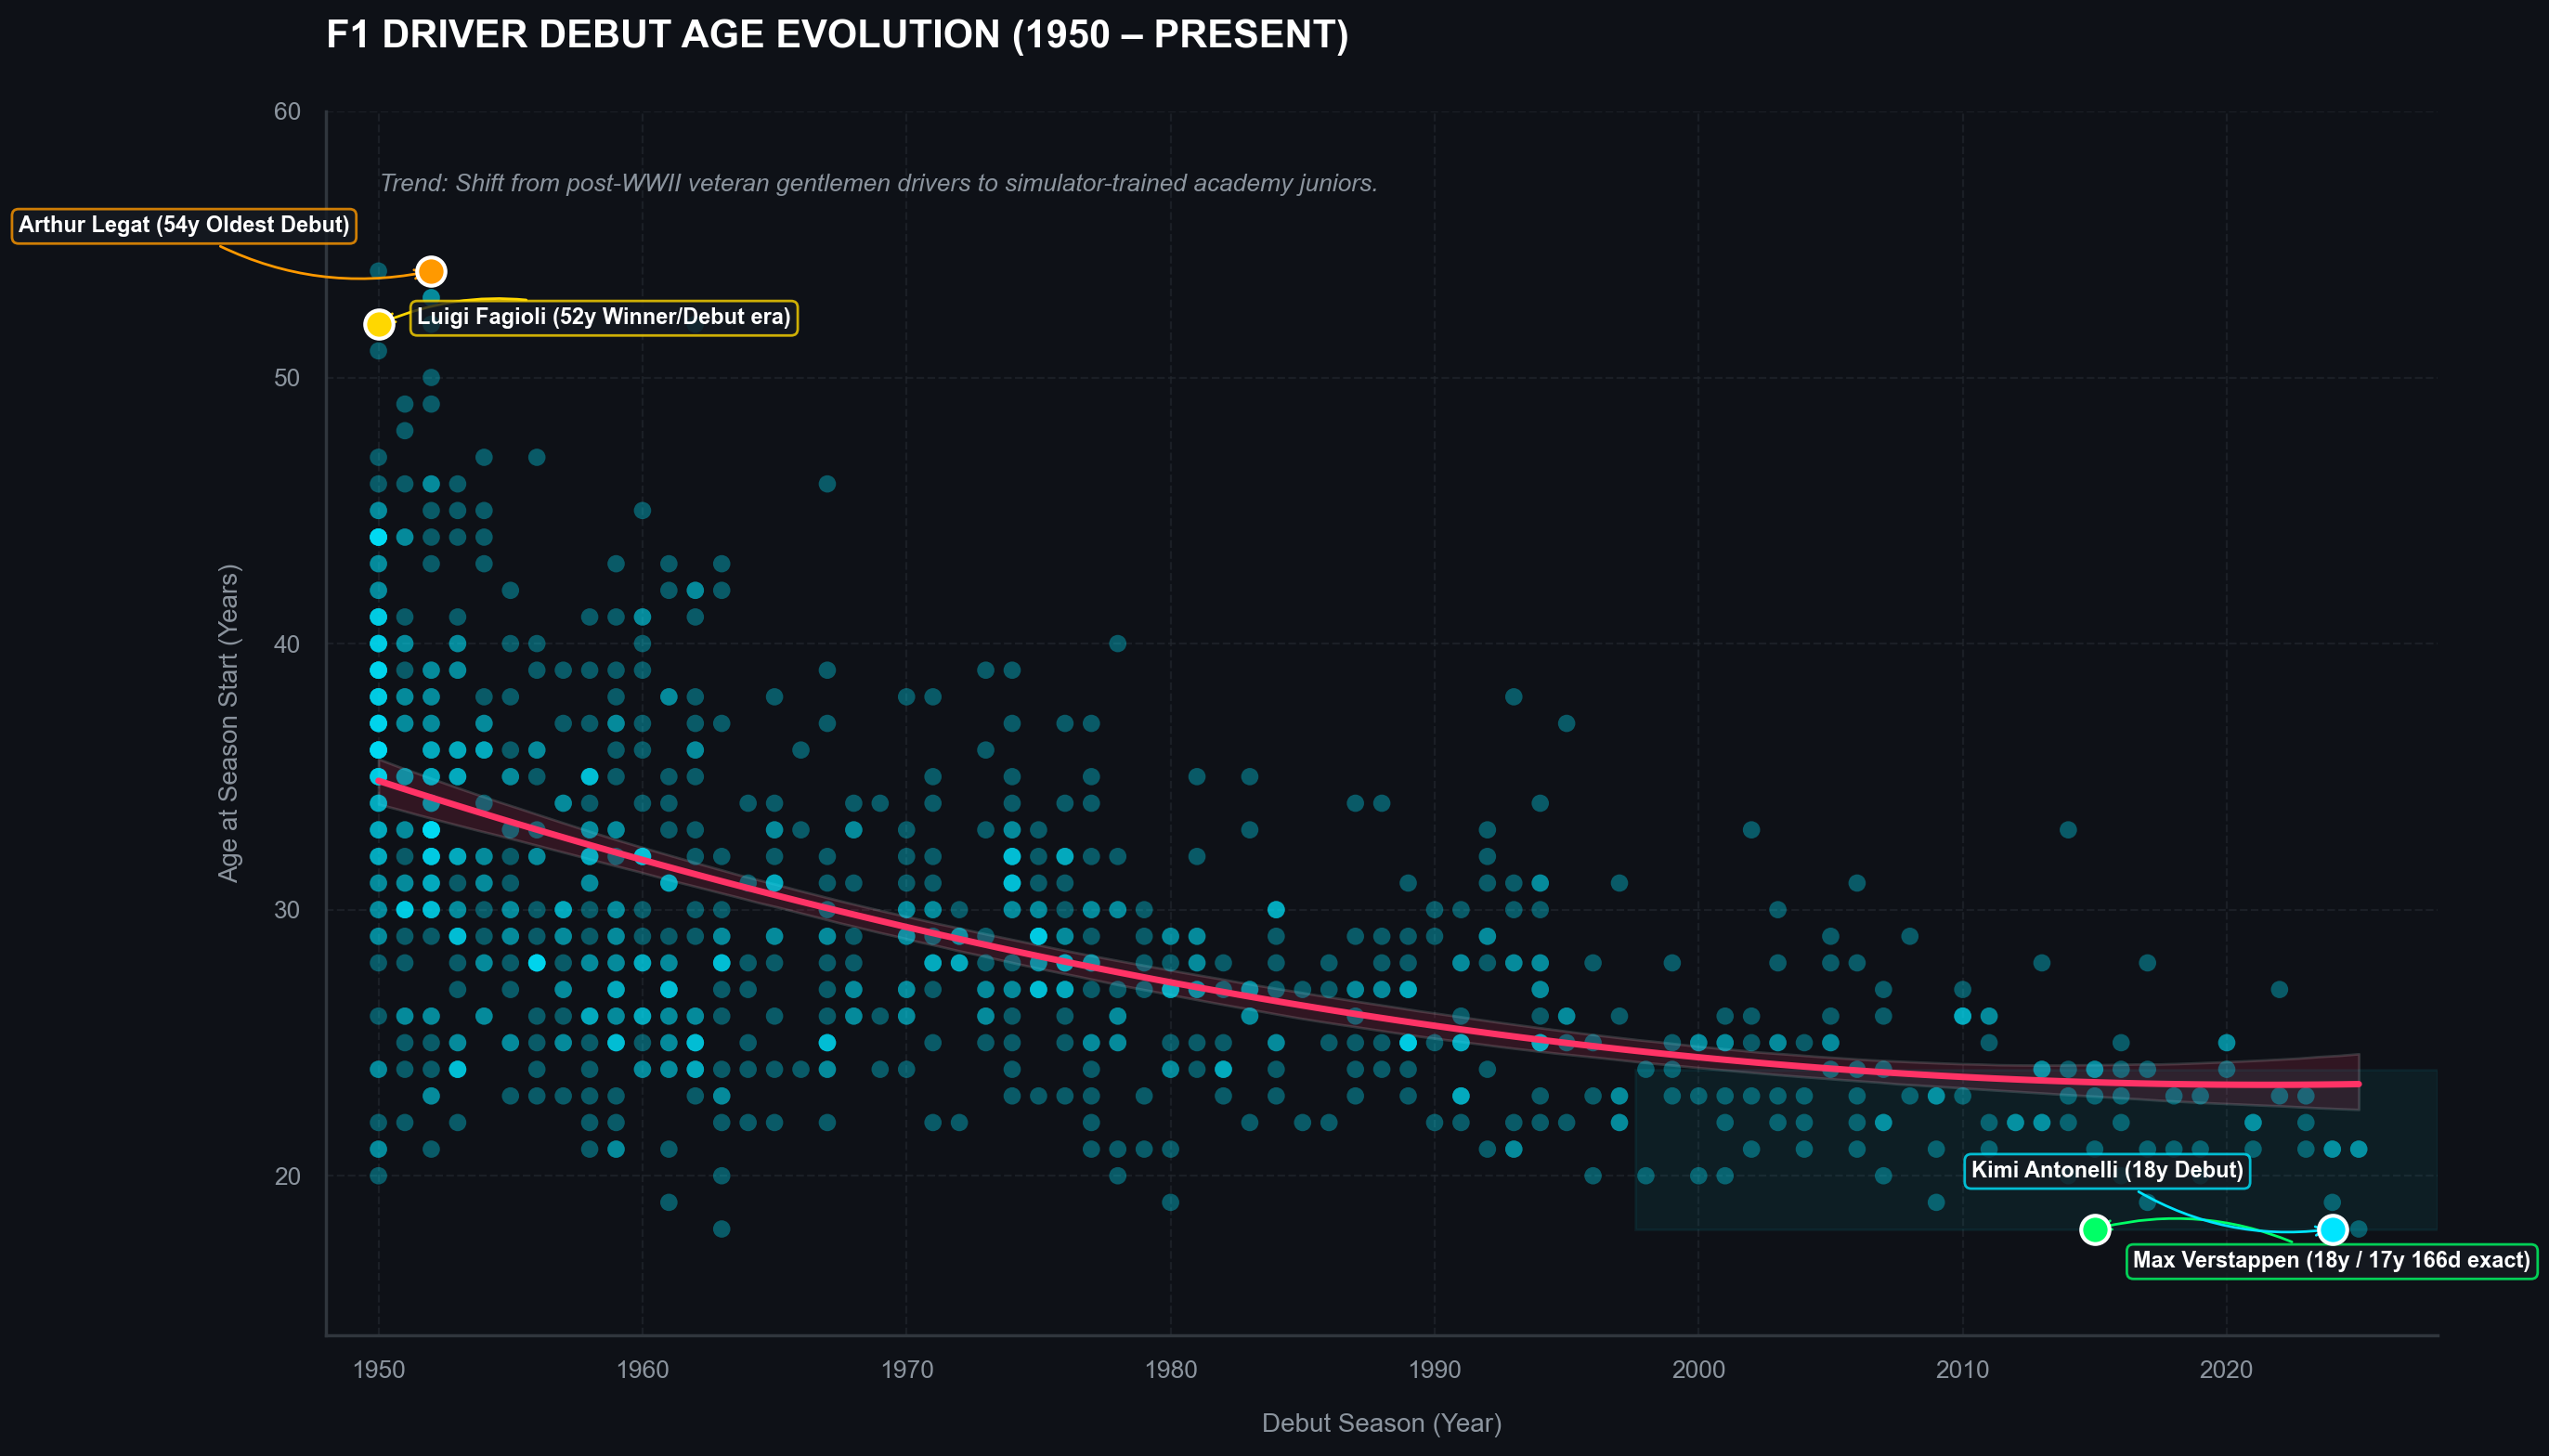

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Custom Studio Theme Settings
plt.figure(figsize=(14, 8), dpi=200)
ax = plt.gca()

# Dark Slate Background (Not pitch black, professional grey/blue)
bg_color = "#0E1117"
card_color = "#161B22"
fig = plt.gcf()
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# 2. Plotting Main Driver Points (Glowing Cyan/Teal Dots)
sns.scatterplot(
    data=debut_df,
    x="debut_year",
    y="debut_age",
    color="#00E5FF",
    alpha=0.35,
    s=45,
    edgecolor="none",
    ax=ax,
    zorder=2,
)

# 3. Non-Linear Polynomial Regression Line (Captures the real curve drop)
sns.regplot(
    data=debut_df,
    x="debut_year",
    y="debut_age",
    scatter=False,
    order=2,  # Smooth curve instead of straight line
    color="#FF3366",
    ax=ax,
    line_kws={"linewidth": 2.5, "linestyle": "-", "zorder": 4},
)

# 4. Highlight Band: Modern Academy Era (Post 2000) Standard Range (18-24 yrs)
ax.axhspan(
    18,
    24,
    xmin=0.62,
    xmax=1.0,
    color="#00F0FF",
    alpha=0.06,
    zorder=1,
    label="Modern Entry Zone (18-24)",
)

# 5. Highlighting Specific Driver Outliers with Glowing Rings & Callouts
annotations = [
    # (driver_name, label_text, color, xytext_offset)
    (
        "Max Verstappen",
        "Max Verstappen (18y / 17y 166d exact)",
        "#00FF66",
        (15, -15),
    ),
    (
        "Andrea Kimi Antonelli",
        "Kimi Antonelli (18y Debut)",
        "#00E5FF",
        (-140, 20),
    ),
    ("Luigi Fagioli", "Luigi Fagioli (52y Winner/Debut era)", "#FFD700", (15, 0)),
    ("Arthur Legat", "Arthur Legat (54y Oldest Debut)", "#FF9900", (-160, 15)),
]

for driver_name, label, color, offset in annotations:
    match = debut_df[debut_df["driver_full_name"] == driver_name]
    if not match.empty:
        row = match.iloc[0]
        # Draw outer ring dot
        ax.scatter(
            row["debut_year"],
            row["debut_age"],
            color=color,
            s=120,
            edgecolors="#FFFFFF",
            linewidth=1.5,
            zorder=5,
        )

        # Callout Text with Pointer Line
        ax.annotate(
            label,
            (row["debut_year"], row["debut_age"]),
            xytext=offset,
            textcoords="offset points",
            color="#FFFFFF",
            fontsize=8.5,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor=card_color,
                edgecolor=color,
                alpha=0.8,
                linewidth=1,
            ),
            arrowprops=dict(
                arrowstyle="->", connectionstyle="arc3,rad=0.2", color=color, lw=1
            ),
        )

# 6. Aesthetic Axis & Grid Formatting
ax.set_title(
    "F1 DRIVER DEBUT AGE EVOLUTION (1950 – PRESENT)",
    fontsize=15,
    fontweight="bold",
    pad=25,
    color="#FFFFFF",
    loc="left",
)
ax.set_xlabel("Debut Season (Year)", fontsize=10, color="#8B949E", labelpad=12)
ax.set_ylabel(
    "Age at Season Start (Years)", fontsize=10, color="#8B949E", labelpad=12
)

# Custom Spines (Clean borders)
for spine in ax.spines.values():
    spine.set_color("#30363D")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Grid Tuning
ax.grid(True, color="#21262D", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)

# Tick Tuning
ax.tick_params(colors="#8B949E", labelsize=9.5)
ax.set_ylim(14, 60)
ax.set_xlim(1948, 2028)

# Subtle Subtitle Annotation inside Plot
ax.text(
    1950,
    57,
    "Trend: Shift from post-WWII veteran gentlemen drivers to simulator-trained academy juniors.",
    fontsize=9.5,
    fontstyle="italic",
    color="#8B949E",
)

plt.tight_layout()
plt.show()

> **Overview & Analytical Objective**
This visualization tracks the age of every Formula 1 driver at their debut season start across seven decades of racing history ($1950–2025+$). The primary goal is to examine how athletic requirements, junior driver pipelines, and team recruitment strategies have reshaped the entry age profile of F1 drivers over time.

---

 > **Key Analytical Insights**

* **The Veteran Era ($1950\text{s}–1960\text{s}$):** 
  In F1's inaugural decades, debut ages frequently spanned from late 30s to mid-50s. The post-WWII era relied heavily on experienced sports car drivers and affluent gentlemen racers (e.g., **Arthur Legat** at 54 years old and **Luigi Fagioli** at 52 years old).

* **The Academy Shift & Structural Decline:** 
  The second-order polynomial regression curve demonstrates a continuous downward trajectory in debut age. By the late 1990s and 2000s, structural changes—such as formal karting pipelines, simulator training, and dedicated F1 Junior Driver Academies—reduced the average entry age down to ~20–23 years.

* **The Modern Entry Zone ($18–24$ Years):** 
  The highlighted modern band illustrates the structural cap of modern driver development. Talent is scouted early and fast-tracked through FIA F3/F2 feeder series, yielding extreme modern debutants like **Max Verstappen** ($17\text{y } 166\text{d}$ exact debut age) and **Kimi Antonelli** ($18\text{y}$ season entry).

---

**Data Methodology Note**
* **Debut Age Calculation:** Computed as $\text{Debut Season Year} - \text{Birth Year}$.
* **Precision Note:** Exact day-level entry ages (such as Max Verstappen’s record at 17 years, 166 days) will be refined further by integrating race-level timestamp datasets (`races.csv`) in downstream modules.

### **Analysis 5 : Team Longetivity**
______________________________________________

In [47]:
team_span = (
    driver_career_df.groupby(["team_id","name"])
    .agg(
        first_year = ("year","min"),
        last_year = ("year","max"),
        seasons_active = ("year","nunique"),
        unique_drivers=("driver_id","nunique")
    )
    .assign(
        years_span = lambda d : d["last_year"]-d["first_year"] +1
    )
    .sort_values("seasons_active",ascending=False).reset_index()
)

team_span.head(15)

,team_id,name,first_year,last_year,seasons_active,unique_drivers,years_span
0,6,Ferrari,1950,2026,77,102,77
1,117,McLaren,1968,2026,57,58,59
2,141,Williams,1975,2026,51,65,52
3,58,Team Lotus,1958,1994,29,61,37
4,123,Tyrrell,1970,1998,29,47,29
5,152,Renault,1977,2020,24,26,44
6,182,Sauber,1993,2025,24,32,33
7,34,BRM,1951,1977,23,70,27
8,191,Red Bull,2005,2026,22,17,22
9,83,Brabham,1962,1992,22,49,31


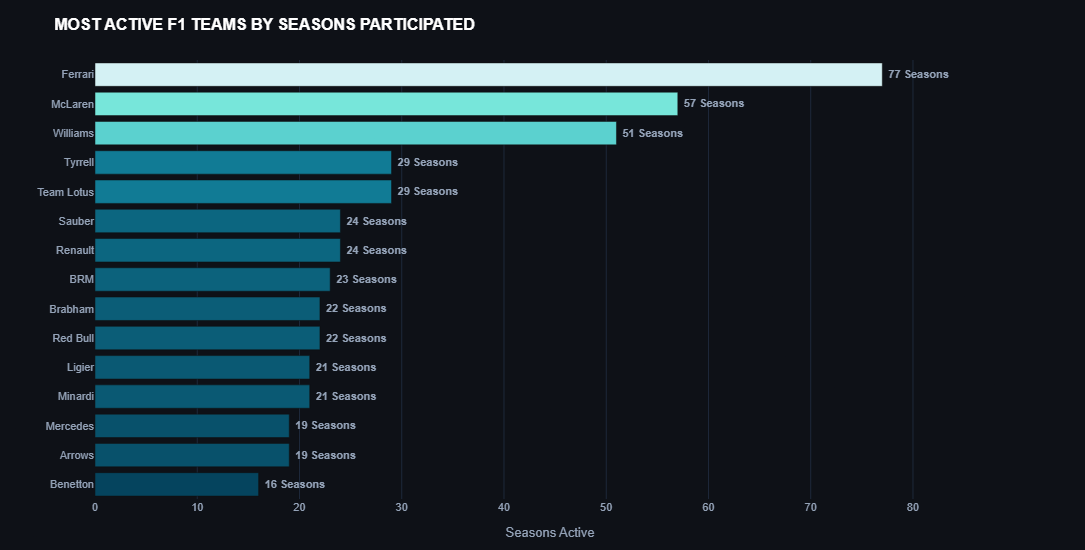

In [48]:
import plotly.express as px

# Top 15 teams sorted by SEASONS_ACTIVE
top_active_teams = team_span.sort_values(
    "seasons_active", ascending=True
).tail(15)

# Executive Color Palette: Smooth Dark Teal -> Electric Cyan Gradient
fig = px.bar(
    top_active_teams,
    x="seasons_active",
    y="name",
    orientation="h",
    color="seasons_active",
    # Single smooth gradient (No ugly multi-color rainbow)
    color_continuous_scale=["#05445E", "#189AB4", "#75E6DA", "#D4F1F4"],
    text="seasons_active",
    custom_data=[
        "first_year",
        "last_year",
        "years_span",
        "unique_drivers",
    ],
    title="<b>MOST ACTIVE F1 TEAMS BY SEASONS PARTICIPATED</b>",
)

# Custom Hover & Clean Bar Text
fig.update_traces(
    texttemplate=" <b>%{text} Seasons</b>",
    textposition="outside",
    hovertemplate=(
        "<b>%{y}</b><br><br>"
        "Seasons Active: <b>%{x}</b><br>"
        "Active Era: %{customdata[0]} – %{customdata[1]} (%{customdata[2]} Yrs)<br>"
        "Drivers Raced: <b>%{customdata[3]}</b>"
        "<extra></extra>"
    ),
)

# Minimal Dark Slate Theme
fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="#0E1117",  # Slate Dark Canvas
    plot_bgcolor="#0E1117",
    height=550,
    title_font=dict(size=16, color="#FFFFFF", family="Inter, sans-serif"),
    xaxis_title="Seasons Active",
    yaxis_title="",
    coloraxis_showscale=False,  # Colorbar removed for sleek view
    font=dict(family="Inter, sans-serif", size=11, color="#94A3B8"),
    margin=dict(l=20, r=80, t=60, b=40),
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="#1E293B",
    zeroline=False,
    range=[0, top_active_teams["seasons_active"].max() + 12],
)
fig.update_yaxes(showgrid=False)

fig.show()

# Notebook me ye chalakar HTML save kar lo
fig.write_html("f1_historic_constructors.html")

### **Analysis 6 : Roster stability**
_______________________________________________

In [49]:
team_stability = team_span.copy()
team_stability["drivers_per_season"] = (
    team_stability["unique_drivers"]/team_stability["seasons_active"]
)
stable_teams = (
    team_stability[team_stability["seasons_active"]>=15].sort_values("drivers_per_season")
    .head(15)
)

stable_teams

,team_id,name,first_year,last_year,seasons_active,unique_drivers,years_span,drivers_per_season
13,48,Mercedes,1954,2026,19,14,73,0.736842
8,191,Red Bull,2005,2026,22,17,22,0.772727
1,117,McLaren,1968,2026,57,58,59,1.017544
15,167,Benetton,1986,2001,16,17,16,1.062500
5,152,Renault,1977,2020,24,26,44,1.083333
2,141,Williams,1975,2026,51,65,52,1.274510
0,6,Ferrari,1950,2026,77,102,77,1.324675
6,182,Sauber,1993,2025,24,32,33,1.333333
11,146,Ligier,1976,1996,21,28,21,1.333333
14,1,Alfa Romeo,1950,2023,16,23,74,1.437500


> Red Bull didn't just find a driver. They found a lifestyle.

>McLaren's been running the same playbook since 1968 — one seat, one loyalty, six decades.

>Mercedes doesn't rotate drivers. It adopts them.

>Some teams collect trophies. Some teams collect drivers. Jordan and Team Lotus? Definitely the second one.
>
>**Reality check**: this table still isn't "who won the most" — a team could be super loyal to a driver who never wins a race. Actual dominance (championships, wins) is next on the list once we hit the `teamchampionship` table.

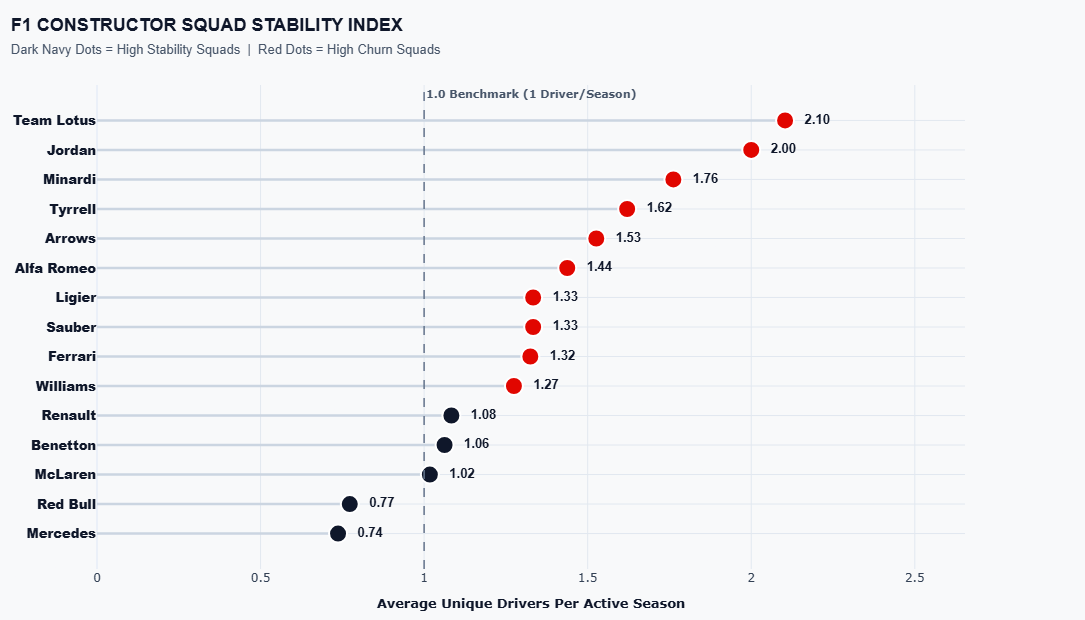

In [50]:
import plotly.graph_objects as go

# 1. Prepare Data (Sorted by Drivers Per Season)
plot_df = stable_teams.sort_values("drivers_per_season", ascending=True)

fig = go.Figure()

# 2. Add Horizontal Lines (Lollipops Stem)
for idx, row in plot_df.iterrows():
    fig.add_trace(
        go.Scatter(
            x=[0, row["drivers_per_season"]],
            y=[row["name"], row["name"]],
            mode="lines",
            line=dict(color="#CBD5E1", width=2.5),
            showlegend=False,
            hoverinfo="skip",
        )
    )

# 3. Add End Marker Dots (Colors based on Stability Threshold)
# Deep Navy Blue for High Stability (< 1.2), Coral Red for High Churn (>= 1.2)
colors = [
    "#0F172A" if val < 1.2 else "#E10600"
    for val in plot_df["drivers_per_season"]
]

fig.add_trace(
    go.Scatter(
        x=plot_df["drivers_per_season"],
        y=plot_df["name"],
        mode="markers+text",
        marker=dict(
            color=colors,
            size=18,
            line=dict(color="#FFFFFF", width=2),
        ),
        text=[f"  <b>{val:.2f}</b>" for val in plot_df["drivers_per_season"]],
        textposition="middle right",
        textfont=dict(size=13, color="#0F172A", family="Arial"),
        customdata=plot_df[
            ["seasons_active", "unique_drivers", "first_year", "last_year"]
        ],
        hovertemplate=(
            "<div style='padding: 8px; font-family: Inter, sans-serif; background: #FFFFFF; border-radius: 4px;'>"
            "<b style='font-size: 15px; color: #0F172A;'>%{y}</b><br><br>"
            "<b>Drivers/Season Ratio:</b> %{x:.2f}<br>"
            "<b>Total Drivers Raced:</b> %{customdata[1]}<br>"
            "<b>Seasons Active:</b> %{customdata[0]}<br>"
            "<b>Active Era:</b> %{customdata[2]} – %{customdata[3]}<br>"
            "</div>"
            "<extra></extra>"
        ),
        showlegend=False,
    )
)

# 4. Reference Line (Industry Average Threshold)
fig.add_vline(
    x=1.0,
    line_dash="dash",
    line_color="#64748B",
    line_width=1.5,
    annotation_text="<b>1.0 Benchmark (1 Driver/Season)</b>",
    annotation_position="top right",
    annotation_font=dict(size=11, color="#475569"),
)

# 5. Crisp Executive Layout
fig.update_layout(
    template="plotly_white",
    paper_bgcolor="#F8F9FA",
    plot_bgcolor="#F8F9FA",
    height=620,
    title=dict(
        text="<b>F1 CONSTRUCTOR SQUAD STABILITY INDEX</b><br><span style='font-size: 13px; color: #475569;'>Dark Navy Dots = High Stability Squads  |  Red Dots = High Churn Squads</span>",
        font=dict(size=18, color="#0F172A", family="Arial"),
        x=0.01,
        y=0.95,
    ),
    xaxis=dict(
        title="<b>Average Unique Drivers Per Active Season</b>",
        title_font=dict(size=13, color="#0F172A"),
        tickfont=dict(size=12, color="#334155"),
        gridcolor="#E2E8F0",
        gridwidth=1,
        range=[0, plot_df["drivers_per_season"].max() + 0.55],
    ),
    yaxis=dict(
        tickfont=dict(size=13, color="#0F172A", family="Arial Black"),
        gridcolor="#E2E8F0",
    ),
    margin=dict(l=20, r=120, t=85, b=50),
)

fig.show()

## **Championship Table**
**This section contain some flaws, and analyses served here lead to future use, and not to give sudden results**
___________________________

In [51]:
driverchamp_df = tables["formula_one_driverchampionship"]

print(driverchamp_df.shape)
print(driverchamp_df.columns.tolist())

(36003, 14)
['id', 'adjustment_type', 'driver_id', 'highest_finish', 'is_eligible', 'points', 'position', 'round_id', 'round_number', 'season_id', 'session_id', 'session_number', 'win_count', 'year']


In [52]:
pd.set_option('display.max_rows', 500)
driverchamp_df.head(5)

,id,adjustment_type,driver_id,highest_finish,is_eligible,points,position,round_id,round_number,season_id,session_id,session_number,win_count,year
0,425647,0,847,NaN,t,0.0,1.0,NaN,1,NaN,5134,4,0,2026
1,425648,0,857,NaN,t,0.0,2.0,NaN,1,NaN,5134,4,0,2026
2,425649,0,795,NaN,t,0.0,3.0,NaN,1,NaN,5134,4,0,2026
3,425650,0,845,NaN,t,0.0,4.0,NaN,1,NaN,5134,4,0,2026
4,425651,0,864,NaN,t,0.0,5.0,NaN,1,NaN,5134,4,0,2026


In [53]:
total_rows = len(driverchamp_df)
unique_ids = driverchamp_df["id"].nunique()

print(f"\nTotal rows : {total_rows}")
print(f"Unique 'id' values: {unique_ids}")


Total rows : 36003
Unique 'id' values: 36003


In [54]:
session_df = tables["formula_one_session"]
sample_ids = [5134, 5135, 5136, 5137, 5142, 5143, 5144, 5145]

session_df[session_df["id"].isin(sample_ids)][["id","round_id","number","type","timestamp"]]

,id,round_id,number,type,timestamp
4953,5134,1174,4.0,Q1,2026-03-07 05:00:00+00:00
4954,5135,1174,5.0,Q2,2026-03-07 05:00:00+00:00
4955,5136,1174,6.0,Q3,2026-03-07 05:00:00+00:00
4956,5137,1174,7.0,R,2026-03-08 04:00:00+00:00
4961,5142,1175,5.0,SR,2026-03-14 03:00:00+00:00
4962,5143,1175,6.0,Q1,2026-03-14 07:00:00+00:00
4963,5144,1175,7.0,Q2,2026-03-14 07:00:00+00:00
4964,5145,1175,8.0,Q3,2026-03-14 07:00:00+00:00


In [55]:
sample = driverchamp_df[
    (driverchamp_df["year"] == 2026) &
    (driverchamp_df["round_number"] == 2) &
    (driverchamp_df["driver_id"] == 847)
]

sample[["session_id", "session_number", "points", "position", "win_count", "round_id"]]

,session_id,session_number,points,position,win_count,round_id
82,5142,5,33.0,1.0,1,NaN
104,5143,6,33.0,1.0,1,NaN
126,5144,7,33.0,1.0,1,NaN
148,5145,8,33.0,1.0,1,NaN
35299,5146,9,51.0,1.0,1,1175.0


**Do `round_id` is filled only for Race session (R) ?**

In [56]:
merged_check = driverchamp_df.merge(
    session_df[["id", "type"]],
    left_on="session_id", right_on="id",
    suffixes=("", "_session")
)

round_id_by_type = (
    merged_check
    .groupby("type")["round_id"]
    .apply(lambda x: x.notna().mean())
    .sort_values(ascending=False)
)

round_id_by_type

type
R     1.0
Q1    0.0
Q2    0.0
Q3    0.0
SR    0.0
Name: round_id, dtype: float64

**Cleaning for Race Only dataset**

In [57]:
race_standings = driverchamp_df[driverchamp_df["round_id"].notna()].copy()
print(f"Original_rows : {len(driverchamp_df)}")
print(f"Race-only rows : {len(race_standings)}")

Original_rows : 36003
Race-only rows : 34818


In [58]:
duplicate_check = race_standings.duplicated(subset=["driver_id", "round_id"]).sum()
print(f"Duplicate driver+round combos: {duplicate_check}")

Duplicate driver+round combos: 0


In [59]:
rounds_in_race_standings = race_standings["round_id"].nunique()
avg_entries_per_round = len(race_standings) / rounds_in_race_standings

print(f"Unique rounds in race_standings : {rounds_in_race_standings}")
print(f"Average entries per round        : {avg_entries_per_round:.1f}")

Unique rounds in race_standings : 1158
Average entries per round        : 30.1


In [60]:
race_standings.head()

,id,adjustment_type,driver_id,highest_finish,is_eligible,points,position,round_id,round_number,season_id,session_id,session_number,win_count,year
60,425707,0,847,1.0,t,25.0,1.0,1174.0,1,NaN,5137,7,1,2026
61,425708,0,863,2.0,t,18.0,2.0,1174.0,1,NaN,5137,7,0,2026
62,425709,0,843,3.0,t,15.0,3.0,1174.0,1,NaN,5137,7,0,2026
63,425710,0,795,4.0,t,12.0,4.0,1174.0,1,NaN,5137,7,0,2026
64,425711,0,845,5.0,t,10.0,5.0,1174.0,1,NaN,5137,7,0,2026


In [61]:
sample_season = race_standings[
    (race_standings["driver_id"] == 847) &
    (race_standings["season_id"].isna() == False)  # placeholder, adjust below if season_id mostly NaN
]

# season_id NaN ho sakta hai (jaisa humne pehle dekha), to year use karte hain
sample_season = race_standings[
    (race_standings["driver_id"] == 847) &
    (race_standings["year"] == 2026)
].sort_values("round_number")

sample_season[["round_number", "position", "points", "win_count"]]

,round_number,position,points,win_count
60,1,1.0,25.0,1
35299,2,1.0,51.0,1
35388,3,2.0,63.0,1
35498,4,2.0,80.0,1
35608,5,2.0,88.0,1
35697,6,3.0,88.0,1
35785,7,3.0,106.0,1
35872,8,2.0,131.0,2
35982,9,2.0,154.0,2


> **Initially attempted to compute wins from driverchampionship.win_count/position, but verification against known values (Hamilton's 106 wins) revealed this table tracks cumulative championship standing, not per-race results. Cross-checked with formula_one_session.type and pivoted to sessionentry — the correct per-race results table**

>**computed standings output through code has been deleted here, above analyses are preserved for analysis purpose**

>**We will use another tables to get driver/teams result per rounds**

## **Race result**
______________

In [62]:
sessionentry_df = tables["formula_one_sessionentry"]
roundentry_df = tables["formula_one_roundentry"]

race_session_ids = session_df[session_df["type"] == "R"]["id"]

race_results = sessionentry_df[sessionentry_df["session_id"].isin(race_session_ids)]

print(f"Total sessionentry rows : {len(sessionentry_df)}")
print(f"Race-only rows          : {len(race_results)}")

# Sanity check: sirf ek row per round_entry_id per race honi chahiye
race_results["round_entry_id"].duplicated().sum()

Total sessionentry rows : 50706
Race-only rows          : 26071


np.int64(0)

In [63]:
race_results = sessionentry_df[sessionentry_df["session_id"].isin(race_session_ids)]

driver_race_results = (
    race_results
    .merge(
        roundentry_df[["id", "round_id", "team_driver_id"]],
        left_on="round_entry_id", right_on="id",
        suffixes=("", "_roundentry")
    )
    .merge(
        teamdriver_df[["id", "driver_id", "team_id"]],
        left_on="team_driver_id", right_on="id",
        suffixes=("", "_teamdriver")
    )
    .merge(
        driver_df[["id", "forename", "surname"]],
        left_on="driver_id", right_on="id",
        suffixes=("", "_driver")
    )
    .merge(
        round_df[["id", "season_id"]],
        left_on="round_id", right_on="id",
        suffixes=("", "_round")
    )
    .merge(
        season_df[["id", "year"]],
        left_on="season_id", right_on="id",
        suffixes=("", "_season")
    )
)

# Row count check — pre vs post
print(f"race_results rows       : {len(race_results)}")
print(f"driver_race_results rows: {len(driver_race_results)}")

race_results rows       : 26071
driver_race_results rows: 26071


In [64]:
driver_race_results.head(5)

,id,api_id,detail,fastest_lap_rank,grid,is_classified,is_eligible_for_points,laps_completed,points,position,round_entry_id,session_id,status,time,id_roundentry,round_id,team_driver_id,id_teamdriver,driver_id,team_id,id_driver,forename,surname,id_round,season_id,id_season,year
0,1,sessionentry_AJVCqvHP,Finished,NaN,1.0,t,t,70.0,9.0,1.0,1,1,0.0,02:13:23.6,1,1,1,1,1,1,1,Nino,Farina,1,1,1,1950
1,2,sessionentry_nTuoeGU3,Finished,NaN,2.0,t,t,70.0,6.0,2.0,2,1,0.0,02:13:26.2,2,1,2,2,2,1,2,Luigi,Fagioli,1,1,1,1950
2,3,sessionentry_YtaG16NK,Finished,NaN,4.0,t,t,70.0,4.0,3.0,3,1,0.0,02:14:15.6,3,1,3,3,3,1,3,Reg,Parnell,1,1,1,1950
3,4,sessionentry_1vAEWr3Z,+2 Laps,NaN,6.0,t,t,68.0,3.0,4.0,4,1,1.0,None,4,1,4,4,4,5,4,Yves,Cabantous,1,1,1,1950
4,5,sessionentry_nycFnYH2,+2 Laps,NaN,9.0,t,t,68.0,2.0,5.0,5,1,1.0,None,5,1,5,5,5,5,5,Louis,Rosier,1,1,1,1950


### **Analysis 1 : Highest number of wins per driver**
_________________

In [65]:
race_wins_final = (
    driver_race_results[driver_race_results["position"]==1]
    .groupby("driver_id")
    .size().reset_index(name="total_wins")
    .merge(driver_df[["id","forename","surname"]],left_on ="driver_id", right_on = "id")
    .assign(driver_full_name = lambda d : d["forename"]+" "+d["surname"])
    .sort_values("total_wins",ascending = False)
    .head(15)
)

race_wins_final[["driver_full_name","total_wins"]]

,driver_full_name,total_wins
100,Lewis Hamilton,106
81,Michael Schumacher,91
108,Max Verstappen,71
102,Sebastian Vettel,53
71,Alain Prost,51
75,Ayrton Senna,41
94,Fernando Alonso,32
72,Nigel Mansell,31
40,Jackie Stewart,27
32,Jim Clark,25


In [66]:
plot_df = race_wins_final.head(15).sort_values("total_wins", ascending=True)

# 2. Create Plotly Express Horizontal Bar Chart
fig = px.bar(
    plot_df,
    x="total_wins",
    y="driver_full_name",
    orientation="h",
    text="total_wins",
    title="<b>ALL-TIME FORMULA 1 RACE WINNERS</b>",
    labels={
        "total_wins": "Total Grand Prix Wins",
        "driver_full_name": "Driver Name",
    },
    color="total_wins",
    color_continuous_scale="Blues",  # Electric Blue gradient
)

# 3. Clean Styling (No Bar Outlines + Blue Glow Vibe)
fig.update_traces(
    textposition="outside",
    cliponaxis=False,
    hovertemplate="<b>%{y}</b><br>Grand Prix Wins: <b>%{x}</b><extra></extra>",
    marker=dict(line=dict(width=0)),  # Completely removes bar outlines/strips
)

fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="#0A0E17",  # Deep slate/navy background
    plot_bgcolor="#0A0E17",
    font=dict(family="Arial, sans-serif", color="#E2E8F0"),
    title_font=dict(size=22, color="#38BDF8"),  # Vibrant blue header
    xaxis=dict(
        showgrid=True,
        gridcolor="#1E293B",  # Subtle grid lines
        zeroline=False,
        title_font=dict(size=14, color="#94A3B8"),
    ),
    yaxis=dict(showgrid=False, title=None, tickfont=dict(size=13)),
    coloraxis_showscale=False,  # Hide colorbar for clean minimalist look
    height=600,
    margin=dict(l=50, r=60, t=80, b=50),
)

# Render Plot
fig.show()

### **Analysis 2 : WIn Rate Per driver**
_________

In [67]:
driver_race_counts = (
    driver_race_results.groupby("driver_id")
    .size().reset_index(name="total_races")
)
win_rate_df = (
    race_wins_final.merge(
        driver_race_counts,on="driver_id"
    )
    .assign( win_rate = lambda d : (d["total_wins"]/d["total_races"] *100).round(1))
    .sort_values("win_rate",ascending=False)
)

win_rate_df[win_rate_df["total_races"] >= 20][["driver_full_name","total_wins","total_races","win_rate"]].head(15)

,driver_full_name,total_wins,total_races,win_rate
11,Juan Fangio,24,58,41.4
9,Jim Clark,25,73,34.2
1,Michael Schumacher,91,308,29.5
2,Max Verstappen,71,242,29.3
0,Lewis Hamilton,106,389,27.2
8,Jackie Stewart,27,100,27.0
5,Ayrton Senna,41,161,25.5
4,Alain Prost,51,202,25.2
14,Damon Hill,22,116,19.0
3,Sebastian Vettel,53,300,17.7


In [68]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Filter Top 6 Drivers
top_drivers = win_rate_df[win_rate_df["total_races"] >= 20].head(6)

# 2. Subplot titles me hi Driver Name aur Wins/Races subtitle clean format me daal diya
titles = [
    f"<b>{row['driver_full_name']}</b><br><span style='font-size:12px;color:#94A3B8;'>{int(row['total_wins'])} Wins / {int(row['total_races'])} Races</span>"
    for _, row in top_drivers.iterrows()
]

# Grid setup: vertical_spacing badhayi hai taaki top aur bottom rows me gap rahe
fig = make_subplots(
    rows=2,
    cols=3,
    specs=[[{"type": "indicator"}] * 3] * 2,
    subplot_titles=titles,
    vertical_spacing=0.25,
    horizontal_spacing=0.1,
)

positions = [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3)]

# 3. Add Gauge Indicators
for idx, (_, row) in enumerate(top_drivers.iterrows()):
    r, c = positions[idx]
    fig.add_trace(
        go.Indicator(
            mode="gauge+number",
            value=row["win_rate"],
            number={
                "suffix": "%",
                "font": {"color": "#00F2FE", "size": 28, "family": "Arial"},
            },
            # Indicator Title 'None' kar diya taaki Subplot Title ke sath overlap na ho
            title=None,
            gauge={
                "axis": {
                    "range": [0, 50],
                    "tickwidth": 1,
                    "tickcolor": "#334155",
                    "tickfont": {"size": 10, "color": "#64748B"},
                },
                "bar": {"color": "#00F2FE", "thickness": 0.75},
                "bgcolor": "#0F172A",
                "borderwidth": 0,
                "steps": [
                    {"range": [0, 20], "color": "#1E293B"},
                    {"range": [20, 35], "color": "#0F294A"},
                    {"range": [35, 50], "color": "#024170"},
                ],
            },
        ),
        row=r,
        col=c,
    )

# 4. Final Layout Adjustments
fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="#050811",
    plot_bgcolor="#050811",
    title=dict(
        text="<b>TOP 6 F1 DRIVERS: CAREER WIN RATE GAUGES</b>",
        font=dict(size=20, color="#38BDF8"),
        x=0.04,
        y=0.96,
    ),
    height=580,
    margin=dict(l=40, r=40, t=90, b=40),
)

# Subplot titles ki styling adjustment (Overlapping Fix)
for annotation in fig["layout"]["annotations"]:
    annotation["font"] = dict(color="#F8FAFC", size=14)
    annotation["y"] = annotation["y"] + 0.02  # Text ko thoda upar shift kiya

fig.show()

In [69]:
wins_rank_df = (
    race_wins_final.head(15)
    .reset_index(drop=True)
    .assign(rank_wins=lambda d: range(1, len(d) + 1))
)

# Merge race counts to compute Win Rate
merged_df = wins_rank_df.merge(driver_race_counts, on="driver_id").assign(
    win_rate=lambda d: (d["total_wins"] / d["total_races"] * 100).round(1)
)

# Calculate Win Rate Rank among these top drivers
merged_df["rank_rate"] = (
    merged_df["win_rate"].rank(ascending=False, method="min").astype(int)
)

# Sort for plotting clean slope lines
merged_df = merged_df.sort_values("rank_wins")

# 2. Build High-Tech Rank Comparison (Slope Chart)
fig = go.Figure()

# Custom Neon Colors for Top Drivers
colors = [
    "#00F2FE",
    "#38BDF8",
    "#818CF8",
    "#C084FC",
    "#F472B6",
    "#34D399",
    "#FBBF24",
    "#A7F3D0",
    "#60A5FA",
    "#93C5FD",
]

for idx, row in merged_df.iterrows():
    line_color = colors[idx % len(colors)]
    rank_change = row["rank_wins"] - row["rank_rate"]

    # Slope Line (Left: Total Wins Rank ---> Right: Win Rate Rank)
    fig.add_trace(
        go.Scatter(
            x=["Total Wins Rank", "Win Rate Rank"],
            y=[row["rank_wins"], row["rank_rate"]],
            mode="lines+markers+text",
            line=dict(color=line_color, width=3),
            marker=dict(size=10, color=line_color, symbol="circle"),
            name=row["driver_full_name"],
            text=[
                f"<b>{row['driver_full_name']}</b> (#{row['rank_wins']})",
                f"<b>{row['driver_full_name']}</b> (#{row['rank_rate']})",
            ],
            textposition=["middle left", "middle right"],
            textfont=dict(color="#E2E8F0", size=11),
            hovertemplate=(
                f"<b>{row['driver_full_name']}</b><br>"
                + f"Total Wins: <b>{int(row['total_wins'])}</b> (Rank #{row['rank_wins']})<br>"
                + f"Win Rate: <b>{row['win_rate']}%</b> (Rank #{row['rank_rate']})<br>"
                + f"Total Races: <b>{int(row['total_races'])}</b>"
                + "<extra></extra>"
            ),
            showlegend=False,
        )
    )

# 3. Layout Adjustments (Y-Axis Inverted so Rank #1 stays on TOP)
fig.update_layout(
    template="plotly_dark",
    title=dict(
        text="<b>DRIVER RANK SHIFT: TOTAL WINS vs WIN RATE</b><br><sup>Slope analysis showing volume dominance vs efficiency rank shift</sup>",
        font=dict(size=20, color="#38BDF8"),
        x=0.03,
        y=0.95,
    ),
    paper_bgcolor="#050811",
    plot_bgcolor="#050811",
    xaxis=dict(
        showgrid=False,
        tickfont=dict(size=14, color="#00F2FE", family="Arial"),
        range=[-0.5, 1.5],  # Padding for text labels
    ),
    yaxis=dict(
        title="Rank Position",
        autorange="reversed",  # Rank 1 at top
        showgrid=True,
        gridcolor="#1E293B",
        tickmode="linear",
        tick0=1,
        dtick=1,
        tickfont=dict(color="#94A3B8"),
    ),
    height=650,
    margin=dict(l=80, r=80, t=100, b=50),
)

fig.show()

### **Analysis 2 : Highest number of wins per constructor/Team**
_________

In [70]:
team_wins = (
    driver_race_results[driver_race_results["position"]==1]
    .groupby("team_id")
    .size()
    .reset_index(name="total_wins")
    .merge(team_df[["id","name"]],left_on ="team_id",right_on = "id")
    .sort_values("total_wins",ascending =False)
    .head(15)
)

team_wins[["name","total_wins"]]

,name,total_wins
2,Ferrari,251
26,McLaren,199
8,Mercedes,138
39,Red Bull,130
32,Williams,114
12,Team Lotus,45
35,Renault,35
36,Benetton,27
17,Brabham,23
28,Tyrrell,23


### **Analysis 3 : Teams with most wins per decade**
_________

In [71]:
driver_race_results["decade"]=(driver_race_results["year"]//10)*10

decade_wins = (
    driver_race_results[driver_race_results["position"]==1]
    .groupby(["decade","team_id"])
    .size().reset_index(name="wins")
    .merge(team_df[["id","name"]], left_on = "team_id", right_on = "id")
)

top_team_per_decade = (
    decade_wins.sort_values(["decade","wins"],ascending =[True,False])
    .groupby("decade")
    .head(3)
    .reset_index(drop=True)
)

top_team_per_decade[["decade","name","wins"]]

,decade,name,wins
0,1950,Ferrari,30
1,1950,Alfa Romeo,11
2,1950,Vanwall,10
3,1960,Lotus-Climax,22
4,1960,Ferrari,13
5,1960,BRM,12
6,1970,Ferrari,37
7,1970,Team Lotus,35
8,1970,Tyrrell,21
9,1980,McLaren,56


### **Analysis 4 : Teams with most win ratio**
______

In [72]:
team_race_presence = (
    driver_race_results
    .groupby("team_id")["round_id"]
    .nunique()
    .reset_index(name="races_entered")
)

team_win_rate = (
    team_wins
    .merge(team_race_presence, on="team_id")
    .assign(win_rate=lambda d: (d["total_wins"] / d["races_entered"] * 100).round(1))
)

# Sirf meaningful sample size - kam se kam 20 races entered
team_win_rate[team_win_rate["races_entered"] >= 20][
    ["name", "total_wins", "races_entered", "win_rate"]
].sort_values("win_rate", ascending=False).head(15)

,name,total_wins,races_entered,win_rate
2,Mercedes,138,350,39.4
10,Lotus-Climax,22,56,39.3
3,Red Bull,130,427,30.4
14,Lotus-Ford,11,43,25.6
0,Ferrari,251,1133,22.2
1,McLaren,199,961,20.7
12,Cooper-Climax,12,66,18.2
4,Williams,114,874,13.0
5,Team Lotus,45,394,11.4
7,Benetton,27,260,10.4


In [73]:
import pandas as pd
import plotly.graph_objects as go

# 1. Base Data Processing (Top 10 Teams sorted by Win Rate)
team_df = (
    team_win_rate[team_win_rate["races_entered"] >= 20]
    .sort_values("win_rate", ascending=False)
    .head(10)
    .sort_values("win_rate", ascending=True)
)

# 2. Build High-Tech Electric Blue/Cyan Scatter Diagram
fig = go.Figure()

# A. Base Connecting Stems
for _, row in team_df.iterrows():
    fig.add_trace(
        go.Scatter(
            x=[0, row["win_rate"]],
            y=[row["name"], row["name"]],
            mode="lines",
            line=dict(color="#1E293B", width=2),
            hoverinfo="none",
            showlegend=False,
        )
    )

# B. Main Interactive Cyan/Blue Nodes
fig.add_trace(
    go.Scatter(
        x=team_df["win_rate"],
        y=team_df["name"],
        mode="markers+text",
        marker=dict(
            size=team_df["races_entered"] / 22 + 12,  # Node scaling
            color=team_df["win_rate"],
            # Electric Azure to Cyan Neon Gradient
            colorscale=[[0.0, "#0052D4"], [0.5, "#4364F7"], [1.0, "#00F2FE"]],
            showscale=False,
            line=dict(width=0),  # No outlines
        ),
        text=[f"  <b>{val}%</b>" for val in team_df["win_rate"]],
        textposition="middle right",
        textfont=dict(color="#00F2FE", size=13, family="Arial"),
        hovertemplate=(
            "<b>%{y}</b><br>"
            + "Win Rate: <b>%{x}%</b><br>"
            + "Total Wins: <b>%{customdata[0]}</b><br>"
            + "Races Entered: <b>%{customdata[1]}</b>"
            + "<extra></extra>"
        ),
        customdata=team_df[["total_wins", "races_entered"]],
        showlegend=False,
    )
)

# C. Multi-Metric Context Label (Wins in Neon Yellow, Races in Slate Blue)
for _, row in team_df.iterrows():
    fig.add_annotation(
        x=0,
        y=row["name"],
        text=f"  <b><span style='color:#FFE600;'>{int(row['total_wins'])} Wins</span></b> / <span style='color:#64748B;'>{int(row['races_entered'])} Races</span>",
        showarrow=False,
        xanchor="left",
        yanchor="bottom",
        font=dict(size=10, family="Arial"),
        yshift=4,
    )

# 3. Layout Styling
fig.update_layout(
    template="plotly_dark",
    title=dict(
        text="<b>F1 CONSTRUCTOR EFFICIENCY: WIN RATE vs TOTAL RACES</b><br><sup>Node size reflects total race entries • Minimum 20 race entries threshold</sup>",
        font=dict(size=18, color="#00F2FE"),
        x=0.03,
        y=0.95,
    ),
    paper_bgcolor="#070A10",
    plot_bgcolor="#070A10",
    xaxis=dict(
        title=dict(text="Win Rate Percentage (%)", font=dict(size=13, color="#94A3B8")),
        showgrid=True,
        gridcolor="#111827",
        zeroline=False,
        range=[0, team_df["win_rate"].max() + 8],
        tickfont=dict(color="#94A3B8"),
    ),
    yaxis=dict(
        showgrid=False,
        tickfont=dict(size=13, color="#F8FAFC", weight="bold"),
        autorange="reversed",  # Rank #1 at top
    ),
    height=620,
    margin=dict(l=140, r=60, t=100, b=60),
)

fig.show()

### **Analysis 5 : Driver wise podium**
____

In [74]:
driver_podiums = (
    driver_race_results[driver_race_results["position"].isin([1,2,3])]
    .groupby("driver_id")
    .size().reset_index(name="total_podiums")
    .merge(
        driver_df[["id","forename","surname"]], left_on = "driver_id",right_on="id"
    )
    .assign(driver_full_name = lambda d : d["forename"]+" "+d["surname"])
    .sort_values("total_podiums", ascending = False)
    .head(15)
)

driver_podiums[["driver_full_name","total_podiums"]]

,driver_full_name,total_podiums
193,Lewis Hamilton,207
165,Michael Schumacher,155
208,Max Verstappen,129
195,Sebastian Vettel,122
139,Alain Prost,106
184,Fernando Alonso,106
183,Kimi Räikkönen,103
149,Ayrton Senna,80
167,Rubens Barrichello,68
204,Valtteri Bottas,67


### **Analysis 6 : Team/COnstructor wise podium**
____

In [75]:
team_podiums = (
    driver_race_results[driver_race_results["position"].isin([1, 2, 3])]
    .groupby("team_id")
    .size()
    .reset_index(name="total_podiums")
    .merge(team_df[["id", "name"]], left_on="team_id", right_on="id")
    .sort_values("total_podiums", ascending=False)
    .head(15)
)

team_podiums[["name", "total_podiums"]]

,name,total_podiums
0,Ferrari,856
6,McLaren,546
1,Mercedes,322
7,Williams,316
9,Red Bull,299
2,Team Lotus,114
8,Benetton,102
3,Cooper-Climax,44
4,Lotus-Climax,31
5,Lotus-Ford,25


### **Analysis 7 : Most wins in the single season (Driver + Team)**
____

In [76]:
driver_season_wins = (
    driver_race_results[driver_race_results["position"] ==1]
    .groupby(["driver_id","year"])
    .size().reset_index(name= "season_wins")
    .merge(driver_df[["id","forename","surname"]], left_on = "driver_id", right_on ="id")
    .assign(driver_full_name = lambda d:d["forename"] + " " + d["surname"])
    .sort_values("season_wins",ascending =False)
    .head(15)
)

driver_season_wins[["driver_full_name","year","season_wins"]]

,driver_full_name,year,season_wins
393,Max Verstappen,2023,19
392,Max Verstappen,2022,15
364,Sebastian Vettel,2013,13
267,Michael Schumacher,2004,13
348,Lewis Hamilton,2014,11
354,Lewis Hamilton,2020,11
265,Michael Schumacher,2002,11
352,Lewis Hamilton,2018,11
353,Lewis Hamilton,2019,11
362,Sebastian Vettel,2011,11


In [77]:
from IPython.display import HTML, display

# 1. Take Top 15 Seasons
top15 = driver_season_wins.head(15).reset_index(drop=True)

# 2. Build High-Tech CSS Grid Layout for 15 Metric Cards
html_code = """
<div style="background-color: #050811; padding: 25px; border-radius: 12px; font-family: Arial, sans-serif; border: 1px solid #1E293B;">
    <div style="margin-bottom: 20px;">
        <h2 style="color: #00F2FE; margin: 0; font-size: 20px; font-weight: bold;">ALL-TIME F1 SINGLE SEASON DOMINANCE</h2>
        <p style="color: #64748B; margin: 5px 0 0 0; font-size: 12px;">Top 15 most victorious individual Formula 1 campaigns in history</p>
    </div>
    
    <div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 14px;">
"""

for idx, row in top15.iterrows():
    rank = idx + 1

    # Custom styling accents based on rank
    if rank == 1:
        border_color = "#FBBF24"  # Gold accent for Rank #1
        rank_bg = "rgba(251, 191, 36, 0.15)"
        rank_text_color = "#FBBF24"
    elif rank in [2, 3]:
        border_color = "#00F2FE"  # Cyan accent for Podium
        rank_bg = "rgba(0, 242, 254, 0.15)"
        rank_text_color = "#00F2FE"
    else:
        border_color = "#1E293B"  # Dark Slate accent for rest
        rank_bg = "rgba(30, 41, 59, 0.5)"
        rank_text_color = "#38BDF8"

    html_code += f"""
        <div style="background: #070A10; border: 1px solid {border_color}; padding: 14px 16px; border-radius: 8px; position: relative;">
            <div style="display: flex; justify-content: space-between; align-items: center;">
                <span style="background: {rank_bg}; color: {rank_text_color}; font-size: 11px; font-weight: bold; padding: 2px 8px; border-radius: 4px;">RANK #{rank}</span>
                <span style="color: #64748B; font-size: 12px; font-weight: bold;">{row['year']}</span>
            </div>
            
            <div style="color: #F8FAFC; font-size: 15px; font-weight: bold; margin-top: 10px;">
                {row['forename']} {row['surname']}
            </div>
            
            <div style="display: flex; align-items: baseline; gap: 6px; margin-top: 6px;">
                <span style="color: {rank_text_color}; font-size: 26px; font-weight: bold;">{row['season_wins']}</span>
                <span style="color: #94A3B8; font-size: 11px; font-weight: bold; letter-spacing: 0.5px;">WINS</span>
            </div>
        </div>
    """

html_code += """
    </div>
</div>
"""

display(HTML(html_code))

In [78]:
team_season_wins = (
    driver_race_results[driver_race_results["position"] == 1]
    .groupby(["team_id", "year"])
    .size()
    .reset_index(name="season_wins")
    .merge(team_df[["id", "name"]], left_on="team_id", right_on="id")
    .sort_values("season_wins", ascending=False)
    .head(15)
)

team_season_wins[["name", "year", "season_wins"]]

,name,year,season_wins
181,Red Bull,2023,21
66,Mercedes,2016,19
180,Red Bull,2022,17
64,Mercedes,2014,16
65,Mercedes,2015,16
40,Ferrari,2002,15
69,Mercedes,2019,15
42,Ferrari,2004,15
112,McLaren,1988,15
135,McLaren,2025,14


### **Analysis 8 : Most points earned in the single season (Driver)**
____

In [79]:
driver_season_points = (
    driver_race_results
    .groupby(["driver_id", "year"])["points"]
    .sum()
    .reset_index(name="season_points")
    .merge(driver_df[["id", "forename", "surname"]], left_on="driver_id", right_on="id")
    .assign(driver_full_name=lambda d: d["forename"] + " " + d["surname"])
    .sort_values("season_points", ascending=False)
    .head(15)
)

driver_season_points[["driver_full_name", "year", "season_points"]]

,driver_full_name,year,season_points
3002,Max Verstappen,2023,530.0
3001,Max Verstappen,2022,433.0
2799,Lewis Hamilton,2019,413.0
2798,Lewis Hamilton,2018,408.0
3003,Max Verstappen,2024,399.0
2827,Sebastian Vettel,2013,397.0
3068,Lando Norris,2025,394.0
2825,Sebastian Vettel,2011,392.0
3004,Max Verstappen,2025,389.0
3000,Max Verstappen,2021,388.5


### **Analysis 9 : Most wins at a single circuit by a driver**
____

In [80]:
driver_circuit_wins =(
    driver_race_results[driver_race_results["position"]==1]
    .merge(round_df[["id","circuit_id"]], left_on = "round_id",right_on= "id")
    .merge(circuit_df[["id","name"]],left_on = "circuit_id", right_on = "id")
    .groupby(
        ["driver_id","name"]
    ).size().reset_index(name="wins_at_circuit")
    .merge(driver_df[["id","forename","surname"]], left_on = "driver_id", right_on = "id")
    .assign(driver_full_name = lambda d : d["forename"] + " " + d["surname"])
    .sort_values("wins_at_circuit", ascending= False)
    .head(15)
)

driver_circuit_wins[["driver_full_name", "name", "wins_at_circuit"]]

,driver_full_name,name,wins_at_circuit
591,Lewis Hamilton,Silverstone Circuit,9
409,Michael Schumacher,Circuit de Nevers Magny-Cours,8
581,Lewis Hamilton,Hungaroring,8
573,Lewis Hamilton,Circuit Gilles Villeneuve,7
575,Lewis Hamilton,Circuit de Barcelona-Catalunya,7
400,Michael Schumacher,Autodromo Enzo e Dino Ferrari,7
406,Michael Schumacher,Circuit Gilles Villeneuve,7
363,Ayrton Senna,Circuit de Monaco,6
421,Michael Schumacher,Suzuka Circuit,6
410,Michael Schumacher,Circuit de Spa-Francorchamps,6


## **Team Championships Tables**
____

In [81]:
teamchamp_df = tables["formula_one_teamchampionship"]

print(teamchamp_df.shape)
print(teamchamp_df.columns.tolist())

(14161, 14)
['id', 'adjustment_type', 'highest_finish', 'is_eligible', 'points', 'position', 'round_id', 'round_number', 'season_id', 'session_id', 'session_number', 'team_id', 'win_count', 'year']


In [82]:
teamchamp_df.head(10)

,id,adjustment_type,highest_finish,is_eligible,points,position,round_id,round_number,season_id,session_id,session_number,team_id,win_count,year
0,197289,0,NaN,t,0.0,1.0,NaN,1,NaN,5134,4,191,0,2026
1,197290,0,NaN,t,0.0,2.0,NaN,1,NaN,5134,4,141,0,2026
2,197291,0,NaN,t,0.0,3.0,NaN,1,NaN,5134,4,64,0,2026
3,197292,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,6,0,2026
4,197293,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,207,0,2026
5,197294,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,48,0,2026
6,197295,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,210,0,2026
7,197296,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,211,0,2026
8,197297,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,117,0,2026
9,197298,0,NaN,f,0.0,NaN,NaN,1,NaN,5134,4,215,0,2026


**Quick hypothesis test that wether this table is commulative?**

In [83]:
sample_team_season = teamchamp_df[
    (teamchamp_df["year"] == 2026) &
    (teamchamp_df["team_id"] == 191) 
].sort_values("session_number")

sample_team_season[["session_id", "session_number", "points", "position", "win_count", "round_id"]]

,session_id,session_number,points,position,win_count,round_id
0,5134,4,0.0,1.0,0,NaN
13824,5150,4,12.0,5.0,0,NaN
14021,5196,4,69.0,4.0,0,NaN
13977,5189,4,57.0,4.0,0,NaN
14065,5203,4,89.0,4.0,0,NaN
13835,5151,5,12.0,5.0,0,NaN
47,5142,5,8.0,4.0,0,NaN
11,5135,5,0.0,1.0,0,NaN
13922,5181,5,32.0,4.0,0,NaN
13867,5172,5,20.0,4.0,0,NaN


### Note — `formula_one_teamchampionship` Table

Verified same structure as `formula_one_driverchampionship`: rows for non-Race sessions (Q1, Q2, Q3, Sprint) carry identical cumulative points/position within a round, and only the Race session row has a populated `round_id`. This confirms the table tracks running championship standings, not per-race results.

**Decision**: Skipped deep analysis of this table — team-level race results (wins, podiums, points) are derived instead from `driver_race_results` (built from `sessionentry`), which already includes `team_id`. This avoids redundant work and keeps a single source of truth for race-level facts.

## **Pitstop Table**
____

In [98]:
pitstop_df = tables["formula_one_pitstop"]

print(pitstop_df.shape)
print(pitstop_df.columns.tolist())
pitstop_df.head(10)

(12672, 8)
['id', 'api_id', 'duration', 'lap_id', 'local_timestamp', 'number', 'session_entry_id', 'duration_seconds']


,id,api_id,duration,lap_id,local_timestamp,number,session_entry_id,duration_seconds
0,1,pitstop_IYavKg2C,00:00:24.036,275638,17:59:17,2,27696,24.036
1,2,pitstop_XDzyA9tn,00:00:22.603,275672,17:25:17,1,27696,22.603
2,3,pitstop_c0OV7PJY,00:00:23.227,275742,17:28:24,1,27700,23.227
3,4,pitstop_SFBiesKg,00:00:23.199,275746,17:59:29,2,27700,23.199
4,5,pitstop_ZS3hcaW8,00:00:24.535,275769,17:28:39,1,27704,24.535
5,6,pitstop_rNxUeXu4,00:00:25.683,275789,17:59:47,2,27704,25.683
6,7,pitstop_MHBgoKH9,00:00:23.251,275826,17:22:34,1,27708,23.251
7,8,pitstop_gjJF69ZM,00:00:24.733,275841,17:46:04,2,27708,24.733
8,9,pitstop_a3BHNNO6,00:00:24.181,275856,18:09:08,3,27708,24.181
9,10,pitstop_9jCnvfPN,00:00:23.426,275886,17:20:48,1,27712,23.426


In [85]:
total_rows = len(pitstop_df)
unique_ids = pitstop_df["id"].nunique()

print(f"Total rows        : {total_rows}")
print(f"Unique 'id' values: {unique_ids}")
print(f"Grain confirmed?   : {total_rows == unique_ids}")

Total rows        : 12672
Unique 'id' values: 12672
Grain confirmed?   : True


In [86]:
print(pitstop_df["duration"].dtype)
pitstop_df["duration"].head(5)

object


0    00:00:24.036
1    00:00:22.603
2    00:00:23.227
3    00:00:23.199
4    00:00:24.535
Name: duration, dtype: object

In [88]:
pitstop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12672 entries, 0 to 12671
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                12672 non-null  int64 
 1   api_id            12672 non-null  object
 2   duration          12672 non-null  object
 3   lap_id            12672 non-null  int64 
 4   local_timestamp   12672 non-null  object
 5   number            12672 non-null  int64 
 6   session_entry_id  12672 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 693.1+ KB


**Checking from which year does this table contain data**

In [89]:
pitstop_with_year = pitstop_df.merge(
    sessionentry_df[["id", "session_id"]],
    left_on="session_entry_id", right_on="id",
    suffixes=("", "_se")
).merge(
    session_df[["id", "round_id"]],
    left_on="session_id", right_on="id",
    suffixes=("", "_sess")
).merge(
    round_df[["id", "season_id"]],
    left_on="round_id", right_on="id",
    suffixes=("", "_round")
).merge(
    season_df[["id", "year"]],
    left_on="season_id", right_on="id",
    suffixes=("", "_season")
)

print(f"Earliest pitstop year: {pitstop_with_year['year'].min()}")
print(f"Latest pitstop year  : {pitstop_with_year['year'].max()}")

Earliest pitstop year: 2011
Latest pitstop year  : 2026


In [90]:
pitstop_df["duration_seconds"] = pd.to_timedelta(pitstop_df["duration"]).dt.total_seconds()
pitstop_df[["duration","duration_seconds"]].head(5)

,duration,duration_seconds
0,00:00:24.036,24.036
1,00:00:22.603,22.603
2,00:00:23.227,23.227
3,00:00:23.199,23.199
4,00:00:24.535,24.535


**Basic Stats and Analysis**

In [91]:
print(f"Average pit stop duration: {pitstop_df['duration_seconds'].mean():.2f} sec")
print(f"Median pit stop duration : {pitstop_df['duration_seconds'].median():.2f} sec")
print(f"Fastest pit stop         : {pitstop_df['duration_seconds'].min():.2f} sec")
print(f"Slowest pit stop         : {pitstop_df['duration_seconds'].max():.2f} sec")

Average pit stop duration: 83.65 sec
Median pit stop duration : 23.58 sec
Fastest pit stop         : 12.80 sec
Slowest pit stop         : 3069.02 sec


In [95]:
print(pitstop_df["duration_seconds"].describe())

# Kitni pitstops 120 seconds (2 min) se zyada hai?
extreme_stops = pitstop_df[pitstop_df["duration_seconds"] > 120]
print(f"\nPit stops over 120 seconds: {len(extreme_stops)}")
extreme_stops[["duration_seconds"]].sort_values("duration_seconds", ascending=False).head(10)

count    12672.000000
mean        83.654341
std        307.004993
min         12.804000
25%         21.904000
50%         23.578500
75%         26.479500
max       3069.017000
Name: duration_seconds, dtype: float64

Pit stops over 120 seconds: 519


,duration_seconds
9172,3069.017
9167,3067.301
9164,3065.174
9170,3063.613
9178,3063.314
9189,3055.732
9154,3055.700
9175,3051.904
9187,3048.950
9149,3046.888


In [96]:
extreme_stops = pitstop_df[pitstop_df["duration_seconds"] > 120].sort_values("duration_seconds", ascending=False)

# Kya ye kisi specific session type se related hain? (jaise Practice sessions, jo ~60-90 min lambi hoti hain)
extreme_check = extreme_stops.merge(
    sessionentry_df[["id", "session_id"]],
    left_on="session_entry_id", right_on="id",
    suffixes=("", "_se")
).merge(
    session_df[["id", "type"]],
    left_on="session_id", right_on="id",
    suffixes=("", "_sess")
)

extreme_check["type"].value_counts()

type
R     500
SR     19
Name: count, dtype: int64

**Note — Extreme Pit Stop Durations (>120 sec)**

>519 pit stops (out of 12,672) show durations exceeding 2 minutes, up to a max of ~51 minutes. All of these occur during **Race (500)** or **Sprint Race (19)** sessions — none during Practice or Qualifying. This confirms these are genuine race-session events, most likely cars sitting in the garage for major repairs after mechanical failure or damage, not data errors. They were excluded from the "typical pit stop duration" analysis using a 120-second cutoff, since they represent a fundamentally different event (breakdown/repair) than a competitive tyre-change stop.

### **Analysis 2 : Pit stop duration trend over years - Does Pit crew skill improved?**
___

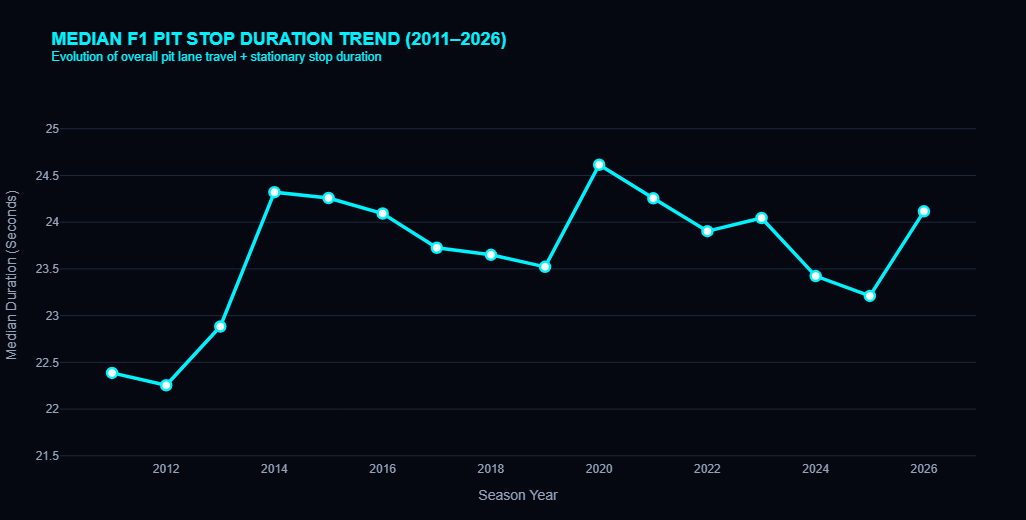

In [94]:
yearly_pitstop = (
    pitstop_with_year.merge(
        pitstop_df[["id", "duration_seconds"]],
        left_on="id",
        right_on="id",
        suffixes=("", "_dur"),
    )
    .groupby("year")["duration_seconds"]
    .median()
    .reset_index()
)

fig = px.line(
    yearly_pitstop,
    x="year",
    y="duration_seconds",
    markers=True,
    title="<b>MEDIAN F1 PIT STOP DURATION TREND (2011–2026)</b><br><sup>Evolution of overall pit lane travel + stationary stop duration</sup>",
    labels={"duration_seconds": "Median Duration (sec)", "year": "Season Year"},
)

fig.update_traces(
    line=dict(color="#00F2FE", width=3.5),  # Electric Neon Cyan Line
    marker=dict(
        size=10,
        color="#F8FAFC",
        line=dict(color="#00F2FE", width=2.5),  # Glowing ring markers
    ),
    text=[f"<b>{val:.2f}s</b>" for val in yearly_pitstop["duration_seconds"]],
    textposition="top center",
    textfont=dict(color="#00F2FE", size=11, family="Arial"),
    hovertemplate="Season: <b>%{x}</b><br>Median Duration: <b>%{y:.3f} sec</b><extra></extra>",
)

# 4. Clean Dark Layout Styling
fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="#050811",
    plot_bgcolor="#050811",
    font=dict(family="Arial, sans-serif", color="#F8FAFC"),
    title_font=dict(size=18, color="#00F2FE"),
    xaxis=dict(
        showgrid=False,
        tickmode="linear",
        dtick=2,
        tickfont=dict(size=12, color="#94A3B8"),
        title=dict(text="Season Year", font=dict(color="#94A3B8")),
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="#1E293B",
        tickfont=dict(size=12, color="#94A3B8"),
        title=dict(text="Median Duration (Seconds)", font=dict(color="#94A3B8")),
        range=[
            yearly_pitstop["duration_seconds"].min() - 0.8,
            yearly_pitstop["duration_seconds"].max() + 0.8,
        ],
    ),
    height=520,
    margin=dict(l=60, r=50, t=90, b=60),
)

fig.show()

**Key Findings — Pit Stop Duration Trend (2011–2026)**

>  - Contrary to the initial assumption that pit stops would simply get faster over time due to technology and crew skill, the actual trend is **non-monotonic** — durations rose sharply after 2013, and have never fully returned to the 2011-2013 baseline (~22.3-22.9 sec) despite 15+ years of practice and equipment development.
>  - Two regulatory events explain the major inflection points:
>  - **2013 Nürburgring incident** led to tightened pit lane safety procedures from 2014 onward, coinciding with the sharp jump from ~22.9 to ~24.3 seconds.
> - **FIA's pit-stop automation clampdown** (mandating human-reaction-time tolerance in pit equipment, after some teams' pit stops became faster than physically explainable by human reflexes) directly explains the 2020 spike to ~24.6 seconds — the FIA deliberately slowed stops down for crew safety.
> - The data also contains extreme outliers (max = 3069 seconds / ~51 minutes) that inflate the raw average (83.65 sec) far beyond the true typical duration (median: 23.58 sec). These outliers almost certainly represent cars parked in the garage for repairs rather than genuine competitive pit stops.

**Interpretation**

>Pit stop duration in F1 is not purely an engineering/performance metric — it's **regulation-bounded**. Teams are technically capable of much faster stops than the data shows (sub-2-second stops have occurred), but the FIA actively caps how fast is "allowed" for safety reasons. This means any cross-era comparison of pit stop speed should be read as "fastest allowed under that era's rules," not "fastest technically achievable."

**Caveat**

>This dataset only covers 2011 onward — pit stop timing wasn't consistently recorded in Jolpica before then, so we cannot compare the modern era against F1's earlier decades (1950s-2000s), when pit stops (with refuelling) commonly took 5+ seconds by design.

In [97]:
pitstop_clean = pitstop_df[pitstop_df["duration_seconds"] <= 120].copy()

print(f"Rows removed as outliers: {len(pitstop_df) - len(pitstop_clean)}")
print(f"Clean average duration  : {pitstop_clean['duration_seconds'].mean():.2f} sec")
print(f"Clean median duration   : {pitstop_clean['duration_seconds'].median():.2f} sec")

Rows removed as outliers: 519
Clean average duration  : 24.60 sec
Clean median duration   : 23.42 sec


## **Analysis 3 : Fastest pit stop ever**
___

In [99]:
fastest_stops = pitstop_clean.nsmallest(10, "duration_seconds")[["duration_seconds", "session_entry_id"]]
fastest_stops

,duration_seconds,session_entry_id
11373,12.804,48715
11413,12.816,48723
1041,12.897,28989
11372,12.910,48715
11412,12.938,48716
1046,12.959,28995
11381,13.078,48723
623,13.173,28449
667,13.186,28489
1695,13.199,29900


### **Analysis 4 : Pit stops per race**
___

In [100]:
stops_per_entry = (
    pitstop_clean
    .groupby("session_entry_id")
    .size()
    .reset_index(name="stops_in_race")
)
print(f"Average stops per car per race: {stops_per_entry['stops_in_race'].mean():.2f}")
stops_per_entry["stops_in_race"].value_counts().sort_index()

Average stops per car per race: 1.95


stops_in_race
1    2324
2    2468
3    1064
4     281
5      89
6      22
Name: count, dtype: int64

### **Analysis 5 : Fastest pit stops by team**
___

In [101]:
pitstop_team = (
    pitstop_clean
    .merge(sessionentry_df[["id", "round_entry_id"]], left_on="session_entry_id", right_on="id", suffixes=("", "_se"))
    .merge(roundentry_df[["id", "team_driver_id"]], left_on="round_entry_id", right_on="id", suffixes=("", "_re"))
    .merge(teamdriver_df[["id", "team_id"]], left_on="team_driver_id", right_on="id", suffixes=("", "_td"))
    .merge(team_df[["id", "name"]], left_on="team_id", right_on="id", suffixes=("", "_team"))
)

team_avg_pitstop = (
    pitstop_team
    .groupby("name")["duration_seconds"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean")
    .head(10)
)
team_avg_pitstop

,mean,count
name,,
Mercedes,23.774308,1187
Red Bull,23.810276,1206
Ferrari,23.847310,1163
McLaren,24.259082,1160
Williams,24.892996,1205


### **Analysis 6 : Pit stop duration distribution**
___

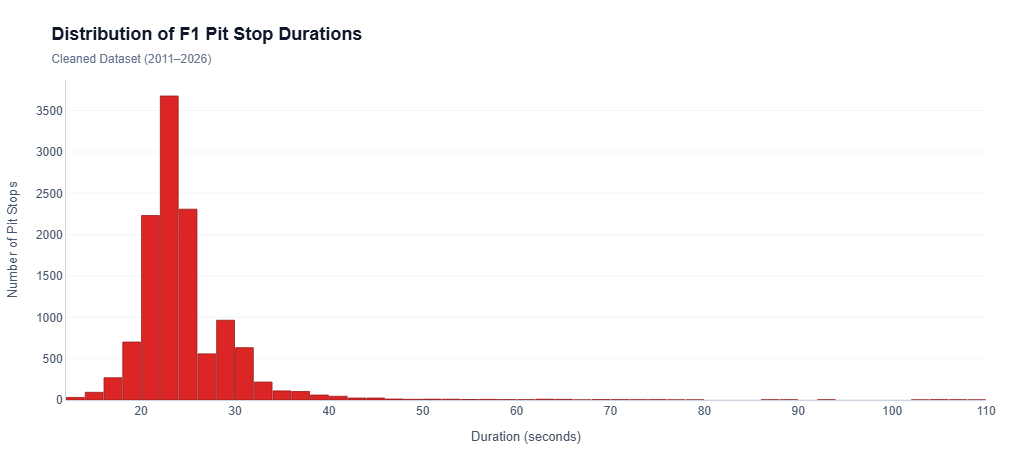

In [104]:
fig = px.histogram(
    pitstop_clean,
    x="duration_seconds",
    nbins=60,
    title="<b>Distribution of F1 Pit Stop Durations</b><br><span style='font-size:12px; color:#64748B;'>Cleaned Dataset (2011–2026)</span>",
    labels={"duration_seconds": "Duration (seconds)"},
)

fig.update_traces(
    marker=dict(
        color="#DC2626",  # Crimson F1 Red
        line=dict(color="#991B1B", width=0.8),  # Subtle darker border
    ),
    hovertemplate="Duration: <b>%{x:.2f}s</b><br>Frequency: <b>%{y:,}</b><extra></extra>",
)

fig.update_layout(
    template="plotly_white",
    paper_bgcolor="#FFFFFF",
    plot_bgcolor="#FFFFFF",
    font=dict(family="Inter, Helvetica, Arial, sans-serif", color="#0F172A"),
    title_font=dict(size=18, color="#0F172A"),
    bargap=0.05,
    xaxis=dict(
        showgrid=False,
        linecolor="#CBD5E1",
        tickfont=dict(size=12, color="#475569"),
        title=dict(text="Duration (seconds)", font=dict(color="#475569", size=13)),
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="#F1F5F9",
        linecolor="#CBD5E1",
        tickfont=dict(size=12, color="#475569"),
        title=dict(text="Number of Pit Stops", font=dict(color="#475569", size=13)),
    ),
    height=460,
    margin=dict(l=60, r=40, t=80, b=60),
)

fig.show()

### **Analysis 7 : Most pit stops in a single race**
___

In [105]:
max_stops_entry = stops_per_entry.sort_values("stops_in_race", ascending=False).head(10)
max_stops_entry

,session_entry_id,stops_in_race
231,28449,6
1818,33775,6
137,28139,6
6116,68941,6
6174,69613,6
1826,33801,6
974,30897,6
5763,50047,6
2454,35949,6
2449,35935,6


## **Formula One Lap Table**
____

In [107]:
lap_df = tables["formula_one_lap"]

print(lap_df.shape)
print(lap_df.dtypes)

total_rows = len(lap_df)
unique_ids = lap_df["id"].nunique()
print(f"\nGrain Confirmed ? : {total_rows == unique_ids}")

(715463, 9)
id                        int64
api_id                   object
average_speed           float64
is_deleted               object
is_entry_fastest_lap     object
number                  float64
position                float64
session_entry_id          int64
time                     object
dtype: object

Grain Confirmed ? : True


In [108]:
print(lap_df["is_deleted"].value_counts())
print("\n")
print(lap_df["time"].head(5))
print(lap_df["time"].dtype)

is_deleted
f    713363
t      2100
Name: count, dtype: int64


0     00:01:16.29
1    00:01:17.554
2    00:01:17.385
3    00:01:18.414
4    00:01:18.194
Name: time, dtype: object
object


**Completeness Check**
___

In [109]:
lap_with_year = lap_df.merge(
    sessionentry_df[["id", "session_id"]],
    left_on="session_entry_id", right_on="id",
    suffixes=("", "_se")
).merge(
    session_df[["id", "round_id"]],
    left_on="session_id", right_on="id",
    suffixes=("", "_sess")
).merge(
    round_df[["id", "season_id"]],
    left_on="round_id", right_on="id",
    suffixes=("", "_round")
).merge(
    season_df[["id", "year"]],
    left_on="season_id", right_on="id",
    suffixes=("", "_season")
)

print(f"Earliest lap-data year: {lap_with_year['year'].min()}")
print(f"Latest lap-data year  : {lap_with_year['year'].max()}")

laps_per_year = lap_with_year.groupby("year").size()
laps_per_year.head(20)

Earliest lap-data year: 1994
Latest lap-data year  : 2026


year
1994      391
1995      394
1996    14576
1997    17425
1998    16326
1999    15868
2000    18065
2001    17379
2002    17392
2003    16352
2004    18947
2005    19670
2006    20768
2007    20370
2008    20262
2009    17945
2010    23501
2011    24942
2012    26343
2013    23681
dtype: int64

**Clean + Convert**

In [110]:
lap_clean = lap_df[lap_df["is_deleted"] == "f"].copy()
lap_clean["lap_seconds"] = pd.to_timedelta(lap_clean["time"]).dt.total_seconds()

print(f"Clean laps: {len(lap_clean)}")
print(lap_clean["lap_seconds"].describe())

Clean laps: 713363
count    713363.000000
mean        100.339125
std          85.812524
min          53.377000
25%          81.969000
50%          91.161000
75%         102.634000
max        7507.547000
Name: lap_seconds, dtype: float64


### **Analysis 1 : All time fastest Laps irrespective of circuit**
___

In [111]:
fastest_laps = (
    lap_clean.nsmallest(10, "lap_seconds")
    .merge(sessionentry_df[["id", "round_entry_id"]], left_on="session_entry_id", right_on="id", suffixes=("", "_se"))
    .merge(roundentry_df[["id", "team_driver_id"]], left_on="round_entry_id", right_on="id", suffixes=("", "_re"))
    .merge(teamdriver_df[["id", "driver_id"]], left_on="team_driver_id", right_on="id", suffixes=("", "_td"))
    .merge(driver_df[["id", "forename", "surname"]], left_on="driver_id", right_on="id", suffixes=("", "_dr"))
)
fastest_laps[["forename", "surname", "lap_seconds"]]

,forename,surname,lap_seconds
0,Valtteri,Bottas,53.377
1,George,Russell,53.403
2,Max,Verstappen,53.433
3,Charles,Leclerc,53.613
4,Max,Verstappen,53.647
5,Sergio,Pérez,53.787
6,Sergio,Pérez,53.790
7,Valtteri,Bottas,53.803
8,Carlos,Sainz,53.818
9,George,Russell,53.819


### **Analysis 2 : Average lap speed trend by year**
___

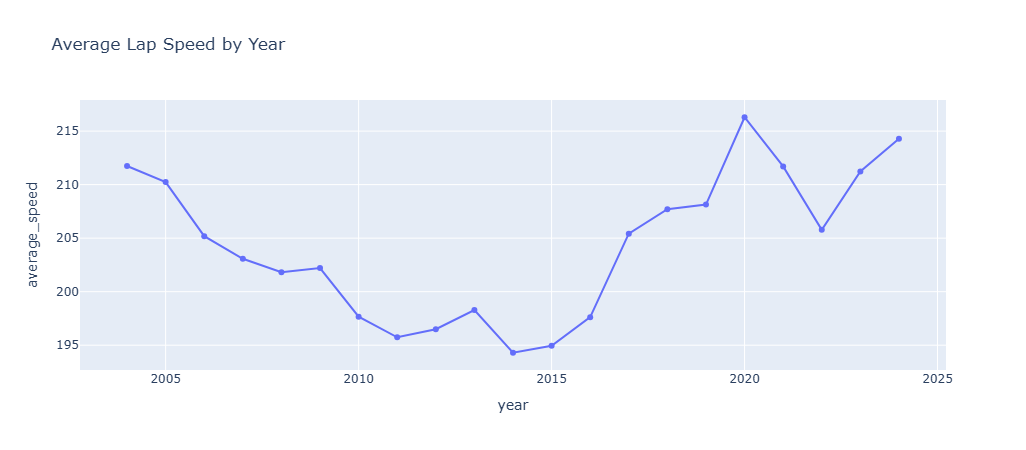

In [112]:
speed_by_year = (
    lap_clean.merge(lap_with_year[["id", "year"]], on="id")
    .groupby("year")["average_speed"]
    .mean()
    .dropna()
    .reset_index()
)

fig = px.line(speed_by_year, x="year", y="average_speed", markers=True,
              title="Average Lap Speed by Year", height=450)
fig.show()

 ### **Analysis 3 : Position changes within a race**
___

In [113]:
position_variance = (
    lap_clean.dropna(subset=["position"])
    .groupby("session_entry_id")["position"]
    .agg(lambda x: x.max() - x.min())
    .reset_index(name="position_range")
)

print(f"Average position range within a race: {position_variance['position_range'].mean():.2f}")
position_variance["position_range"].describe()

Average position range within a race: 5.96


count    12037.00000
mean         5.96328
std          3.56942
min          0.00000
25%          3.00000
50%          6.00000
75%          8.00000
max         22.00000
Name: position_range, dtype: float64

### **Analysis 4 : Top 3 fastest laps over top 10 circuits**
___

In [118]:
team_df = tables["formula_one_team"]
print(team_df.shape)  

(214, 9)


In [119]:
# chain
lap_full = (
    lap_clean
    .merge(sessionentry_df[["id", "round_entry_id"]], left_on="session_entry_id", right_on="id", suffixes=("", "_se"))
    .merge(roundentry_df[["id", "team_driver_id", "round_id"]], left_on="round_entry_id", right_on="id", suffixes=("", "_re"))
    .merge(teamdriver_df[["id", "driver_id", "team_id"]], left_on="team_driver_id", right_on="id", suffixes=("", "_td"))
    .merge(driver_df[["id", "forename", "surname"]], left_on="driver_id", right_on="id", suffixes=("", "_dr"))
    .merge(team_df[["id", "name"]], left_on="team_id", right_on="id", suffixes=("", "_team"))
    .merge(round_df[["id", "circuit_id", "season_id"]], left_on="round_id", right_on="id", suffixes=("", "_rnd"))
    .merge(circuit_df[["id", "name"]], left_on="circuit_id", right_on="id", suffixes=("", "_circ"))
    .merge(season_df[["id", "year"]], left_on="season_id", right_on="id", suffixes=("", "_szn"))
)

print(f"lap_clean rows : {len(lap_clean)}")
print(f"lap_full rows  : {len(lap_full)}")

lap_clean rows : 713363
lap_full rows  : 713363


In [120]:
top_circuits = (
    lap_full["name_circ"].value_counts().head(10).index.tolist()
)

top_circuits_df = lap_full[lap_full["name_circ"].isin(top_circuits)].copy()
top_circuits_df["rank"] = top_circuits_df.groupby("name_circ")["lap_seconds"].rank(method="first")

top3_per_circuit = (
    top_circuits_df[top_circuits_df["rank"] <= 3]
    .sort_values(["name_circ", "lap_seconds"])
    [["name_circ", "forename", "surname", "name", "year", "lap_seconds"]]
)

top3_per_circuit

,name_circ,forename,surname,name,year,lap_seconds
621959,Albert Park Grand Prix Circuit,Lando,Norris,McLaren,2025,75.096
622005,Albert Park Grand Prix Circuit,Oscar,Piastri,McLaren,2025,75.180
621870,Albert Park Grand Prix Circuit,Lando,Norris,McLaren,2025,75.415
648631,Autodromo Nazionale di Monza,Max,Verstappen,Red Bull,2025,78.792
648637,Autodromo Nazionale di Monza,Lando,Norris,McLaren,2025,78.869
495942,Autodromo Nazionale di Monza,Lewis,Hamilton,Mercedes,2020,78.887
460769,Autódromo José Carlos Pace,Lewis,Hamilton,Mercedes,2018,67.281
461139,Autódromo José Carlos Pace,Sebastian,Vettel,Ferrari,2018,67.374
461065,Autódromo José Carlos Pace,Valtteri,Bottas,Mercedes,2018,67.441
470322,Circuit Gilles Villeneuve,Sebastian,Vettel,Ferrari,2019,70.240


## **CONCLUSION**
___
___

### Notebook Conclusion — Jolpica Historical EDA

This notebook set out to understand Formula One through its historical relational database, and to build the analytical foundation for Rahven's VENTURI.

#### What this notebook covered

- **Structural understanding**: verified grain and foreign-key relationships across the core tables (`round`, `circuit`, `season`, `driver`, `team`, `teamdriver`, `sessionentry`, `roundentry`) rather than assuming them from column names.
- **A critical structural discovery**: `formula_one_driverchampionship` and `formula_one_teamchampionship` are cumulative standings trackers, not per-race result tables — verified by tracing session types and confirming that `round_id` is only populated on Race rows. `formula_one_sessionentry` (filtered to Race sessions) was identified as the correct source of truth for race-level results, and every subsequent analysis was built on that verified foundation rather than on assumption.
- **Calendar & circuit history**: F1's growth from 7 races (1950) to 24 (2026), the COVID-era dip, geographic shift toward the Middle East/Americas in recent years, and the small handful of circuits (Monza, Monaco, Silverstone, Spa) that have anchored the calendar for 70+ years.
- **Driver history**: career length and comeback patterns, nationality trends by decade (including uncovering and confirming the 1950s "American driver spike" as an Indianapolis 500 artifact rather than genuine F1 popularity), and the generational shift in debut age from ~35 years (1950s "gentlemen racers") to ~24 years (modern academy pipelines).
- **Team history**: participation/longevity vs. loyalty (drivers-per-season), all-time and single-season wins, win rate by constructor, and podium counts — all cross-verified against known real-world figures (e.g. Hamilton's 106 wins, matched exactly after correcting the initial `driverchampionship`-based miscalculation).
- **Pit stops**: duration trends across 2011-2026, with the counter-intuitive finding that stops got *slower* after 2014 and 2020 due to FIA safety regulation changes — not a simple "technology improves over time" story.
- **Lap data**: verified per-circuit fastest laps (correcting an initial flawed cross-circuit comparison, since circuit lengths vary too much to compare raw lap times directly), and caught a real mid-session data bug (`team_df` silently overwritten) using the row-count-check discipline established early in this notebook.

#### What was intentionally not explored further, and why

- **`formula_one_championshipsystem` / `formula_one_pointsystem`**: lookup/config tables describing how scoring rules changed across eras. Acknowledged as an important caveat (raw points aren't comparable across eras) but not deep-dived here, since they're reference tables rather than sources of new historical insight on their own.
- **`formula_one_baseteam`, `formula_one_penalty`**: both empty in this dataset — nothing to analyze.
- **`formula_one_championshipadjustment`**: only 3 rows — negligible edge-case data, not worth dedicated analysis.
- **Deeper cuts within already-explored tables** (e.g. fastest-lap-bonus tracking, full lap-by-lap speed trends, more granular team-era breakdowns): these are valuable, but are better suited to the next stage of the project rather than this notebook. The goal here was to build verified understanding of the database and surface headline historical insights — not to exhaustively mine every possible cut of every table.

#### Why the notebook stops here

This project's next stage is a **web-hosted platform**, not a longer notebook. The real depth — team profiles, driver comparisons, win-rate/podium-rate/reliability breakdowns per entity, filterable by era — is better built as **reusable backend functions** (e.g. `get_driver_profile(driver_id)`, `get_team_profile(team_id)`) that a website can call on demand, rather than as static cells in a notebook nobody but the author will scroll through. This notebook's job was to establish a *verified, trustworthy foundation* — confirmed grains, confirmed foreign keys, confirmed that `sessionentry` (not `driverchampionship`) is the race-results source of truth — so that those backend functions can be built on solid ground instead of repeating the same debugging discovered here.

#### Next steps

1. Design and implement reusable Python functions (driver profile, team profile, circuit profile, era comparisons) as the data layer for the web backend.
2. Move to FastF1 dataset preparation and feature engineering for the ML/prediction stage of VENTURI.
3. Continue documenting findings for LinkedIn as new analyses emerge from the functionalized data layer.

## A Note on How This Notebook Was Built

This isn't purely solo student work, and it isn't AI-generated content passed off as independent research either — it's somewhere honest in between, and that's worth stating plainly.

I'm not an F1 domain expert going into this — my background was casual (watching races, *Rush*, *Ford v Ferrari*), not deep motorsport knowledge. This is an academic/portfolio project built specifically to learn real data science skills: multi-table relational EDA, foreign-key verification, join validation, and debugging real data issues as they came up.

I wrote and ran every line of code in this notebook myself, with AI assistance — meaning I understand what each piece does and why, not just that it produced an output. I verified results at every step rather than accepting them blindly, and caught real issues along the way (the `driverchampionship` vs `sessionentry` confusion, the `team_df` overwrite bug) by questioning outputs that didn't match known facts. AI helped structure the analytical path — what to check before joining, what order to explore tables in — and some analysis ideas came from my own research into what F1 analyses are typically interesting. A couple of the visualizations (debut-age trend, driver-rank-shift) were built in Gemini from ideas I gave it. The markdown write-ups were a joint effort, but the conclusions and insights in them are ones I understand and can explain, not text I don't stand behind.

> If you're reading this as a recruiter, a peer, or just someone who stumbled onto this project - thank you for taking the time. This project is a genuine attempt to learn end-to-end data work properly, mistakes and corrections included rather than hidden.

— Rahven